# 5) Construccion del Dataset — Particionamiento y Validacion

**Objetivo:** Comparar las estrategias de particionamiento del dataset para clasificacion de genero:
- **2 conjuntos:** Entrenamiento + Pruebas
- **3 conjuntos:** Entrenamiento + Validacion + Pruebas

**Preguntas a responder:**
1. Que diferencia hay en usar un conjunto de validacion?
2. Mejora los resultados en la construccion del modelo?
3. Que informacion provee el uso de un conjunto de validacion?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)

In [2]:
_candidates = [
    "data/gender-classifier-clean.csv",
    "../data/gender-classifier-clean.csv",
    "/app/data/gender-classifier-clean.csv",
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH)
print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Dimensiones: {df.shape}")

Archivo cargado desde: ../data/gender-classifier-clean.csv
Dimensiones: (18836, 26)


## 1. Preparacion de Features

Se reutiliza el pipeline de transformacion del punto 4 (variables categoricas) para construir la matriz de features completa.

In [3]:
# --- Variable objetivo ---
le = LabelEncoder()
y = le.fit_transform(df["gender"])
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- Variables numericas (20 features) ---
var_numericas = [
    "desc_length", "desc_word_count", "text_length", "text_word_count", "name_length",
    "fav_number", "tweet_count", "retweet_count",
    "fav_number_log", "tweet_count_log", "retweet_count_log",
    "link_color_r", "link_color_g", "link_color_b",
    "sidebar_color_r", "sidebar_color_g", "sidebar_color_b",
    "account_age_days", "created_year", "created_month",
]
X_numeric = df[var_numericas].values

# --- One-Hot: user_timezone (top 15 + other) ---
TOP_N_TZ = 15
top_tz = df["user_timezone"].value_counts().head(TOP_N_TZ).index.tolist()
tz_grouped = df["user_timezone"].where(df["user_timezone"].isin(top_tz), other="other")
X_tz = pd.get_dummies(tz_grouped, prefix="tz", dtype=int).values

# --- Frequency Encoding: tweet_location ---
loc_freq = df["tweet_location"].value_counts(normalize=True)
X_loc = df["tweet_location"].map(loc_freq).values.reshape(-1, 1)

# --- TF-IDF: description, text, name ---
tfidf_desc = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_desc = tfidf_desc.fit_transform(df["description"].fillna(""))

tfidf_text = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_text = tfidf_text.fit_transform(df["text"].fillna(""))

tfidf_name = TfidfVectorizer(max_features=200, analyzer="char_wb", ngram_range=(2, 4), min_df=5)
X_name = tfidf_name.fit_transform(df["name"].fillna(""))

# --- Combinar ---
X_dense = np.hstack([X_numeric, X_tz, X_loc])
X = hstack([csr_matrix(X_dense), X_desc, X_text, X_name])

print(f"\nMatriz de features: {X.shape[0]} registros x {X.shape[1]} features")
print(f"Variable objetivo: {len(y)} registros, {len(le.classes_)} clases")

Clases: {'brand': np.int64(0), 'female': np.int64(1), 'male': np.int64(2)}

Matriz de features: 18836 registros x 1237 features
Variable objetivo: 18836 registros, 3 clases


## 2. Teoria: Particionamiento del Dataset

### 2.1 Esquema de 2 conjuntos (Train / Test)

```
Dataset completo
├── Entrenamiento (80%)  →  El modelo aprende de estos datos
└── Pruebas (20%)        →  Se evalua el rendimiento final
```

- El modelo se entrena una sola vez con los datos de entrenamiento.
- Se evalua directamente sobre el conjunto de pruebas.
- **Problema:** Si ajustamos hiperparametros basandonos en los resultados de pruebas, estamos "contaminando" ese conjunto — el modelo se optimiza indirectamente para esos datos.

### 2.2 Esquema de 3 conjuntos (Train / Validation / Test)

```
Dataset completo
├── Entrenamiento (60%)  →  El modelo aprende de estos datos
├── Validacion (20%)     →  Se ajustan hiperparametros aqui
└── Pruebas (20%)        →  Evaluacion final (solo al final)
```

- El modelo se entrena con entrenamiento.
- Se evalua en validacion para **seleccionar hiperparametros** sin tocar los datos de prueba.
- El conjunto de pruebas se usa **solo una vez al final** para reportar el rendimiento real.

### Diferencia clave

| Aspecto | 2 conjuntos | 3 conjuntos |
|---|---|---|
| Ajuste de hiperparametros | Sobre test (sesgo) | Sobre validacion (sin sesgo) |
| Evaluacion final | Potencialmente optimista | Mas realista y confiable |
| Datos para entrenamiento | 80% | 60% (menos datos) |
| Complejidad | Simple | Mas pasos pero mas robusto |

## 3. Experimento A: Particionamiento en 2 Conjuntos (Train / Test)

Se divide el dataset en 80% entrenamiento y 20% pruebas. Se entrena el modelo y se evalua directamente sobre pruebas.

In [4]:
# --- Particionamiento 2 conjuntos: 80% train, 20% test ---
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print("=== Particionamiento en 2 conjuntos ===")
print(f"  Entrenamiento: {X_train_2.shape[0]:>6} registros ({X_train_2.shape[0]/len(y)*100:.0f}%)")
print(f"  Pruebas:       {X_test_2.shape[0]:>6} registros ({X_test_2.shape[0]/len(y)*100:.0f}%)")
print(f"  Total:         {len(y):>6} registros")

=== Particionamiento en 2 conjuntos ===
  Entrenamiento:  15068 registros (80%)
  Pruebas:         3768 registros (20%)
  Total:          18836 registros


In [5]:
# Escalar y entrenar
scaler_2 = MaxAbsScaler()
X_train_2s = scaler_2.fit_transform(X_train_2)
X_test_2s = scaler_2.transform(X_test_2)

# Probar multiples valores de regularizacion C directamente sobre test
# (esto es lo que ocurre cuando no hay conjunto de validacion)
C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
results_2 = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    model.fit(X_train_2s, y_train_2)
    
    acc_train = model.score(X_train_2s, y_train_2)
    acc_test = model.score(X_test_2s, y_test_2)
    results_2.append({"C": C, "acc_train": acc_train, "acc_test": acc_test})
    print(f"C={C:<6} | Train: {acc_train:.4f} | Test: {acc_test:.4f}")

df_results_2 = pd.DataFrame(results_2)
best_2 = df_results_2.loc[df_results_2["acc_test"].idxmax()]
print(f"\nMejor C (segun test): {best_2['C']} → Accuracy test: {best_2['acc_test']:.4f}")

C=0.01   | Train: 0.6544 | Test: 0.6285
C=0.1    | Train: 0.7096 | Test: 0.6576
C=0.5    | Train: 0.7326 | Test: 0.6590
C=1.0    | Train: 0.7382 | Test: 0.6571
C=5.0    | Train: 0.7422 | Test: 0.6534
C=10.0   | Train: 0.7426 | Test: 0.6502

Mejor C (segun test): 0.5 → Accuracy test: 0.6590


## 4. Experimento B: Particionamiento en 3 Conjuntos (Train / Validation / Test)

Se divide el dataset en 60% entrenamiento, 20% validacion y 20% pruebas. Los hiperparametros se ajustan sobre validacion, y el conjunto de pruebas se reserva exclusivamente para la evaluacion final.

In [6]:
# --- Particionamiento 3 conjuntos: 60% train, 20% val, 20% test ---
# Primero separar test (20%), luego dividir el resto en train (75%) y val (25%)
# 80% * 75% = 60% train,  80% * 25% = 20% val
X_temp, X_test_3, y_temp, y_test_3 = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print("=== Particionamiento en 3 conjuntos ===")
print(f"  Entrenamiento: {X_train_3.shape[0]:>6} registros ({X_train_3.shape[0]/len(y)*100:.0f}%)")
print(f"  Validacion:    {X_val_3.shape[0]:>6} registros ({X_val_3.shape[0]/len(y)*100:.0f}%)")
print(f"  Pruebas:       {X_test_3.shape[0]:>6} registros ({X_test_3.shape[0]/len(y)*100:.0f}%)")
print(f"  Total:         {len(y):>6} registros")

=== Particionamiento en 3 conjuntos ===
  Entrenamiento:  11301 registros (60%)
  Validacion:      3767 registros (20%)
  Pruebas:         3768 registros (20%)
  Total:          18836 registros


In [7]:
# Escalar
scaler_3 = MaxAbsScaler()
X_train_3s = scaler_3.fit_transform(X_train_3)
X_val_3s = scaler_3.transform(X_val_3)
X_test_3s = scaler_3.transform(X_test_3)

# Ajustar hiperparametros sobre VALIDACION (no sobre test)
results_3 = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    model.fit(X_train_3s, y_train_3)
    
    acc_train = model.score(X_train_3s, y_train_3)
    acc_val = model.score(X_val_3s, y_val_3)
    results_3.append({"C": C, "acc_train": acc_train, "acc_val": acc_val})
    print(f"C={C:<6} | Train: {acc_train:.4f} | Validacion: {acc_val:.4f}")

df_results_3 = pd.DataFrame(results_3)
best_C = df_results_3.loc[df_results_3["acc_val"].idxmax(), "C"]
print(f"\nMejor C (segun validacion): {best_C}")

C=0.01   | Train: 0.6454 | Validacion: 0.6339
C=0.1    | Train: 0.7098 | Validacion: 0.6767
C=0.5    | Train: 0.7371 | Validacion: 0.6695
C=1.0    | Train: 0.7460 | Validacion: 0.6682
C=5.0    | Train: 0.7547 | Validacion: 0.6602
C=10.0   | Train: 0.7562 | Validacion: 0.6565

Mejor C (segun validacion): 0.1


In [8]:
# Entrenar modelo final con el mejor C, evaluando sobre TEST (primera y unica vez)
model_final_3 = LogisticRegression(C=best_C, max_iter=1000, random_state=SEED)
model_final_3.fit(X_train_3s, y_train_3)

acc_test_3 = model_final_3.score(X_test_3s, y_test_3)
y_pred_3 = model_final_3.predict(X_test_3s)

print(f"=== MODELO FINAL (3 conjuntos, C={best_C}) ===")
print(f"Accuracy en test: {acc_test_3:.4f}\n")
print(classification_report(y_test_3, y_pred_3, target_names=le.classes_))

=== MODELO FINAL (3 conjuntos, C=0.1) ===
Accuracy en test: 0.6542

              precision    recall  f1-score   support

       brand       0.74      0.73      0.73      1189
      female       0.64      0.66      0.65      1340
        male       0.59      0.58      0.59      1239

    accuracy                           0.65      3768
   macro avg       0.66      0.66      0.66      3768
weighted avg       0.65      0.65      0.65      3768



## 5. Que Informacion Provee el Conjunto de Validacion?

El conjunto de validacion permite:
1. **Detectar overfitting**: Si la accuracy de entrenamiento sube pero la de validacion baja, el modelo esta memorizando.
2. **Seleccionar hiperparametros**: Elegir el mejor valor de C sin contaminar el test set.
3. **Comparar modelos**: Evaluar diferentes algoritmos de forma justa.

Visualicemos las curvas de entrenamiento vs validacion:

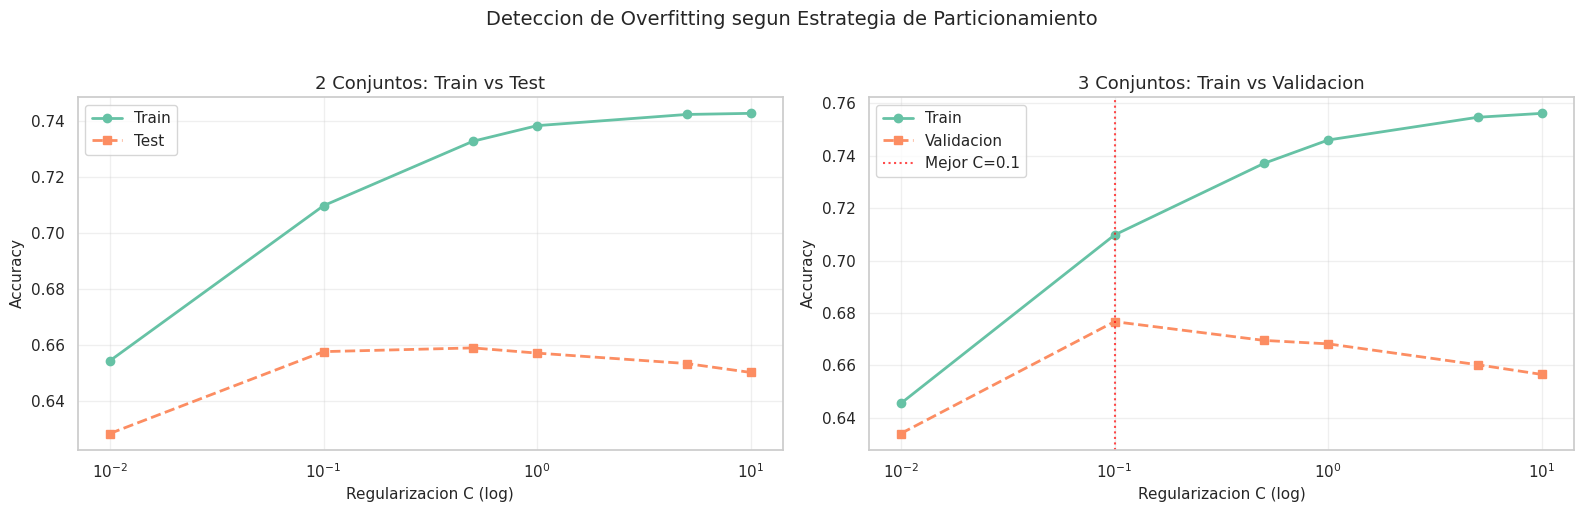

In [9]:
# Curvas de Train vs Validacion para detectar overfitting
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Grafico 1: 2 conjuntos (train vs test) ---
axes[0].plot(df_results_2["C"], df_results_2["acc_train"], "o-", label="Train", linewidth=2)
axes[0].plot(df_results_2["C"], df_results_2["acc_test"], "s--", label="Test", linewidth=2)
axes[0].set_xscale("log")
axes[0].set_xlabel("Regularizacion C (log)", fontsize=11)
axes[0].set_ylabel("Accuracy", fontsize=11)
axes[0].set_title("2 Conjuntos: Train vs Test", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Grafico 2: 3 conjuntos (train vs validacion) ---
axes[1].plot(df_results_3["C"], df_results_3["acc_train"], "o-", label="Train", linewidth=2)
axes[1].plot(df_results_3["C"], df_results_3["acc_val"], "s--", label="Validacion", linewidth=2)
axes[1].axvline(x=best_C, color="red", linestyle=":", alpha=0.7, label=f"Mejor C={best_C}")
axes[1].set_xscale("log")
axes[1].set_xlabel("Regularizacion C (log)", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_title("3 Conjuntos: Train vs Validacion", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Deteccion de Overfitting segun Estrategia de Particionamiento", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Tabla de brecha train-validacion (indicador de overfitting)
print("=== Brecha Train - Validacion (indicador de overfitting) ===\n")
print(f"{'C':<8} {'Train':>10} {'Validacion':>12} {'Brecha':>10} {'Diagnostico'}")
print("-" * 60)
for _, row in df_results_3.iterrows():
    gap = row["acc_train"] - row["acc_val"]
    if gap > 0.05:
        diag = "Overfitting"
    elif gap < 0.01:
        diag = "Underfitting"
    else:
        diag = "Buen balance"
    print(f"{row['C']:<8} {row['acc_train']:>10.4f} {row['acc_val']:>12.4f} {gap:>+10.4f}   {diag}")

=== Brecha Train - Validacion (indicador de overfitting) ===

C             Train   Validacion     Brecha Diagnostico
------------------------------------------------------------
0.01         0.6454       0.6339    +0.0115   Buen balance
0.1          0.7098       0.6767    +0.0331   Buen balance
0.5          0.7371       0.6695    +0.0676   Overfitting
1.0          0.7460       0.6682    +0.0779   Overfitting
5.0          0.7547       0.6602    +0.0945   Overfitting
10.0         0.7562       0.6565    +0.0997   Overfitting


## 6. Comparacion: 2 Conjuntos vs 3 Conjuntos

In [11]:
# Modelo final de 2 conjuntos (usando el mejor C encontrado sobre test)
best_C_2 = best_2["C"]
model_final_2 = LogisticRegression(C=best_C_2, max_iter=1000, random_state=SEED)
model_final_2.fit(X_train_2s, y_train_2)
y_pred_2 = model_final_2.predict(X_test_2s)
acc_test_2 = accuracy_score(y_test_2, y_pred_2)

print(f"=== MODELO 2 CONJUNTOS (C={best_C_2}, seleccionado sobre test) ===")
print(f"Accuracy en test: {acc_test_2:.4f}\n")
print(classification_report(y_test_2, y_pred_2, target_names=le.classes_))

=== MODELO 2 CONJUNTOS (C=0.5, seleccionado sobre test) ===
Accuracy en test: 0.6590

              precision    recall  f1-score   support

       brand       0.76      0.72      0.74      1189
      female       0.64      0.67      0.65      1340
        male       0.59      0.58      0.59      1239

    accuracy                           0.66      3768
   macro avg       0.66      0.66      0.66      3768
weighted avg       0.66      0.66      0.66      3768



In [12]:
# Comparacion lado a lado
print("=" * 65)
print(f"{'COMPARACION DE ESTRATEGIAS DE PARTICIONAMIENTO':^65}")
print("=" * 65)
print(f"{'':>30} {'2 Conjuntos':>15} {'3 Conjuntos':>15}")
print("-" * 65)
print(f"{'Datos de entrenamiento':>30} {'80%':>15} {'60%':>15}")
print(f"{'Datos de validacion':>30} {'N/A':>15} {'20%':>15}")
print(f"{'Datos de pruebas':>30} {'20%':>15} {'20%':>15}")
print(f"{'Mejor C encontrado':>30} {best_C_2:>15} {best_C:>15}")
print(f"{'C seleccionado sobre':>30} {'Test (sesgo)':>15} {'Validacion':>15}")
print(f"{'Accuracy en test':>30} {acc_test_2:>15.4f} {acc_test_3:>15.4f}")
print("=" * 65)
print(f"\nNota: La accuracy del esquema de 2 conjuntos puede parecer")
print(f"igual o superior, pero esta estimacion es OPTIMISTA porque")
print(f"el hiperparametro C fue seleccionado mirando el test set.")
print(f"La accuracy del esquema de 3 conjuntos es mas CONFIABLE")
print(f"porque test nunca se uso para tomar decisiones.")

         COMPARACION DE ESTRATEGIAS DE PARTICIONAMIENTO          
                                   2 Conjuntos     3 Conjuntos
-----------------------------------------------------------------
        Datos de entrenamiento             80%             60%
           Datos de validacion             N/A             20%
              Datos de pruebas             20%             20%
            Mejor C encontrado             0.5             0.1
          C seleccionado sobre    Test (sesgo)      Validacion
              Accuracy en test          0.6590          0.6542

Nota: La accuracy del esquema de 2 conjuntos puede parecer
igual o superior, pero esta estimacion es OPTIMISTA porque
el hiperparametro C fue seleccionado mirando el test set.
La accuracy del esquema de 3 conjuntos es mas CONFIABLE
porque test nunca se uso para tomar decisiones.


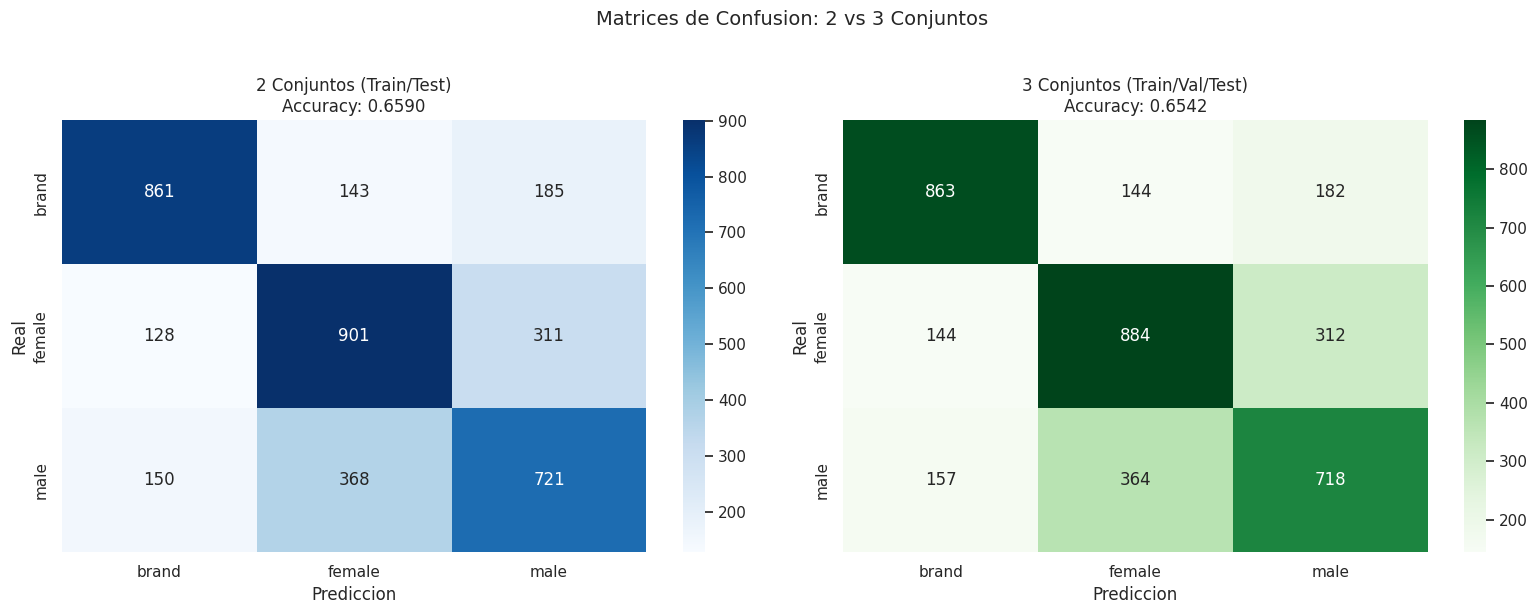

In [13]:
# Matrices de confusion comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_2 = confusion_matrix(y_test_2, y_pred_2)
cm_3 = confusion_matrix(y_test_3, y_pred_3)

sns.heatmap(cm_2, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f"2 Conjuntos (Train/Test)\nAccuracy: {acc_test_2:.4f}", fontsize=12)
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")

sns.heatmap(cm_3, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f"3 Conjuntos (Train/Val/Test)\nAccuracy: {acc_test_3:.4f}", fontsize=12)
axes[1].set_xlabel("Prediccion")
axes[1].set_ylabel("Real")

plt.suptitle("Matrices de Confusion: 2 vs 3 Conjuntos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Complemento: Validacion Cruzada (Cross-Validation)

Una alternativa al conjunto de validacion fijo es la **validacion cruzada (k-fold)**, que divide los datos de entrenamiento en k partes y rota cual se usa como validacion. Esto aprovecha mejor los datos disponibles.

```
Fold 1: [VAL] [Train] [Train] [Train] [Train]  → accuracy_1
Fold 2: [Train] [VAL] [Train] [Train] [Train]  → accuracy_2
Fold 3: [Train] [Train] [VAL] [Train] [Train]  → accuracy_3
Fold 4: [Train] [Train] [Train] [VAL] [Train]  → accuracy_4
Fold 5: [Train] [Train] [Train] [Train] [VAL]  → accuracy_5
                                                  ──────────
                                                  Promedio ± desviacion
```

**Ventajas sobre validacion fija:**
- Usa **todos los datos** tanto para entrenamiento como para validacion.
- Proporciona una **estimacion de varianza** (desviacion estandar entre folds).
- Es mas robusto ante particiones "afortunadas" o "desafortunadas".

In [14]:
# Validacion cruzada para cada valor de C
# Usamos solo los datos de entrenamiento (sin test) para la busqueda
X_trainval = X_train_2s  # 80% de los datos
y_trainval = y_train_2

results_cv = []
print("=== Validacion Cruzada (5-fold) ===\n")
print(f"{'C':<8} {'Media':>10} {'Std':>10} {'Folds':>40}")
print("-" * 72)

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    scores = cross_val_score(model, X_trainval, y_trainval, cv=5, scoring="accuracy")
    results_cv.append({"C": C, "mean": scores.mean(), "std": scores.std(), "scores": scores})
    fold_str = "  ".join(f"{s:.4f}" for s in scores)
    print(f"{C:<8} {scores.mean():>10.4f} {scores.std():>10.4f}   [{fold_str}]")

df_cv = pd.DataFrame(results_cv)
best_cv = df_cv.loc[df_cv["mean"].idxmax()]
print(f"\nMejor C (segun CV): {best_cv['C']} → Accuracy: {best_cv['mean']:.4f} +/- {best_cv['std']:.4f}")

=== Validacion Cruzada (5-fold) ===

C             Media        Std                                    Folds
------------------------------------------------------------------------
0.01         0.6323     0.0080   [0.6387  0.6194  0.6354  0.6409  0.6269]
0.1          0.6644     0.0041   [0.6719  0.6639  0.6646  0.6598  0.6618]
0.5          0.6623     0.0039   [0.6679  0.6566  0.6626  0.6648  0.6595]
1.0          0.6597     0.0059   [0.6685  0.6559  0.6593  0.6631  0.6515]
5.0          0.6515     0.0038   [0.6553  0.6496  0.6490  0.6568  0.6469]
10.0         0.6497     0.0030   [0.6526  0.6466  0.6503  0.6532  0.6459]

Mejor C (segun CV): 0.1 → Accuracy: 0.6644 +/- 0.0041


In [15]:
# Modelo final con C seleccionado por CV, evaluado sobre test
best_C_cv = best_cv["C"]
model_cv = LogisticRegression(C=best_C_cv, max_iter=1000, random_state=SEED)
model_cv.fit(X_trainval, y_trainval)
y_pred_cv = model_cv.predict(X_test_2s)
acc_cv = accuracy_score(y_test_2, y_pred_cv)

print(f"=== MODELO CON CROSS-VALIDATION (C={best_C_cv}) ===")
print(f"Accuracy en test: {acc_cv:.4f}\n")
print(classification_report(y_test_2, y_pred_cv, target_names=le.classes_))

=== MODELO CON CROSS-VALIDATION (C=0.1) ===
Accuracy en test: 0.6576

              precision    recall  f1-score   support

       brand       0.75      0.72      0.74      1189
      female       0.64      0.67      0.65      1340
        male       0.59      0.58      0.59      1239

    accuracy                           0.66      3768
   macro avg       0.66      0.66      0.66      3768
weighted avg       0.66      0.66      0.66      3768



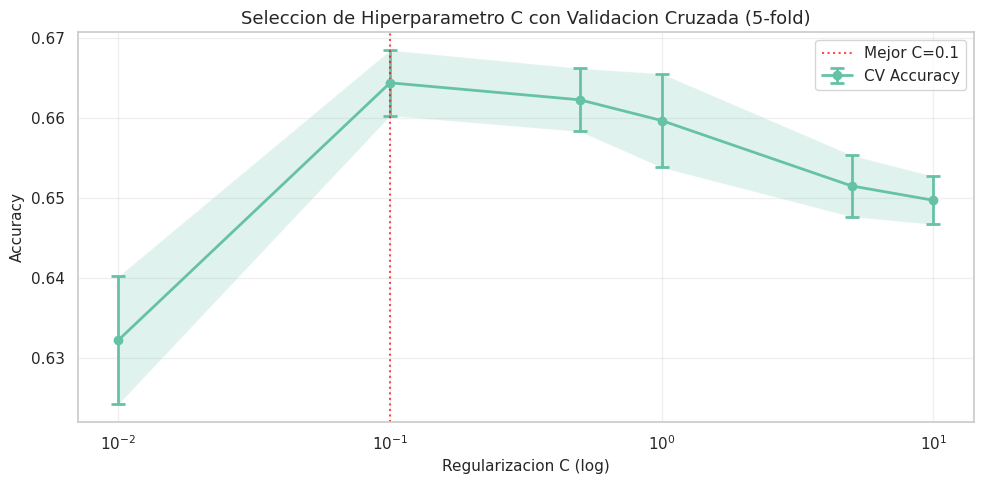

In [16]:
# Visualizacion de Cross-Validation
fig, ax = plt.subplots(figsize=(10, 5))

means = df_cv["mean"].values
stds = df_cv["std"].values
cs = df_cv["C"].values

ax.errorbar(cs, means, yerr=stds, fmt="o-", linewidth=2, capsize=5, capthick=2, label="CV Accuracy")
ax.axvline(x=best_C_cv, color="red", linestyle=":", alpha=0.7, label=f"Mejor C={best_C_cv}")
ax.fill_between(cs, means - stds, means + stds, alpha=0.2)
ax.set_xscale("log")
ax.set_xlabel("Regularizacion C (log)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Seleccion de Hiperparametro C con Validacion Cruzada (5-fold)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Comparacion Final de las 3 Estrategias

                        COMPARACION FINAL DE ESTRATEGIAS                        
                                          2-Split       3-Split   CV (5-fold)
--------------------------------------------------------------------------------
             Datos de entrenamiento           80%           60%  80% (rotado)
             Conjunto de validacion            No     Si (fijo)   Si (rotado)
                            Mejor C           0.5           0.1           0.1
               C seleccionado sobre          Test    Validacion      CV folds
                   Accuracy en test        0.6590        0.6542        0.6576
     Confiabilidad de la estimacion          Baja          Alta      Muy alta


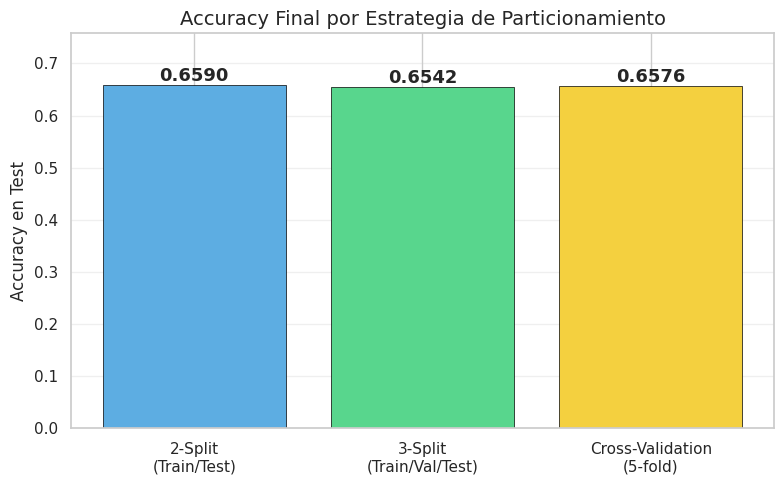

In [17]:
# Tabla comparativa final
print("=" * 80)
print(f"{'COMPARACION FINAL DE ESTRATEGIAS':^80}")
print("=" * 80)
print(f"{'':>35} {'2-Split':>13} {'3-Split':>13} {'CV (5-fold)':>13}")
print("-" * 80)
print(f"{'Datos de entrenamiento':>35} {'80%':>13} {'60%':>13} {'80% (rotado)':>13}")
print(f"{'Conjunto de validacion':>35} {'No':>13} {'Si (fijo)':>13} {'Si (rotado)':>13}")
print(f"{'Mejor C':>35} {best_C_2:>13} {best_C:>13} {best_C_cv:>13}")
print(f"{'C seleccionado sobre':>35} {'Test':>13} {'Validacion':>13} {'CV folds':>13}")
print(f"{'Accuracy en test':>35} {acc_test_2:>13.4f} {acc_test_3:>13.4f} {acc_cv:>13.4f}")
print(f"{'Confiabilidad de la estimacion':>35} {'Baja':>13} {'Alta':>13} {'Muy alta':>13}")
print("=" * 80)

# Grafico de barras
fig, ax = plt.subplots(figsize=(8, 5))
strategies = ["2-Split\n(Train/Test)", "3-Split\n(Train/Val/Test)", "Cross-Validation\n(5-fold)"]
accuracies = [acc_test_2, acc_test_3, acc_cv]
colors = ["#5DADE2", "#58D68D", "#F4D03F"]

bars = ax.bar(strategies, accuracies, color=colors, edgecolor="black", linewidth=0.5)
for bar, acc in zip(bars, accuracies):
    ax.annotate(f"{acc:.4f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_ylabel("Accuracy en Test", fontsize=12)
ax.set_title("Accuracy Final por Estrategia de Particionamiento", fontsize=14)
ax.set_ylim(0, max(accuracies) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Conclusiones

### Pregunta 1: Que diferencia hay en usar un conjunto de validacion?

La diferencia fundamental es la **separacion de responsabilidades**:

- **Sin validacion (2 conjuntos):** El conjunto de pruebas cumple doble rol — se usa tanto para ajustar hiperparametros como para evaluar el modelo final. Esto introduce un **sesgo optimista** porque el modelo se adapta indirectamente a los datos de prueba.

- **Con validacion (3 conjuntos):** Cada conjunto tiene una responsabilidad unica: entrenamiento para aprender, validacion para ajustar hiperparametros, y pruebas exclusivamente para la evaluacion final. Esto garantiza que la evaluacion es **imparcial**.

### Pregunta 2: Mejora los resultados usar un conjunto de validacion?

El conjunto de validacion **no necesariamente mejora la accuracy reportada** — de hecho, la accuracy con 2 conjuntos puede ser igual o mayor porque esta inflada por el sesgo de seleccion. Lo que mejora es:

- La **confiabilidad** de la estimacion del rendimiento.
- La **capacidad de generalizacion** del modelo, ya que los hiperparametros se seleccionan sin contaminar el test set.
- La **deteccion de overfitting**, que es invisible sin un conjunto de validacion separado.

Ademas, la validacion cruzada maximiza el uso de datos al rotar el conjunto de validacion, lo cual es especialmente beneficioso cuando el dataset es limitado.

### Pregunta 3: Que informacion provee el uso de un conjunto de validacion?

El conjunto de validacion provee informacion critica que no esta disponible con solo 2 conjuntos:

1. **Diagnostico de overfitting:** La brecha entre accuracy de entrenamiento y validacion revela si el modelo esta memorizando o generalizando. Como vimos en las curvas de la seccion 5, valores altos de C (menor regularizacion) producen brechas mas grandes.

2. **Seleccion objetiva de hiperparametros:** Permite elegir el mejor valor de C (o cualquier hiperparametro) sin "hacer trampa" mirando los datos de prueba.

3. **Estimacion de varianza (con CV):** La validacion cruzada proporciona no solo un puntaje promedio sino tambien su desviacion estandar, indicando que tan estable es el modelo ante diferentes particiones de datos.

4. **Comparacion justa entre modelos:** Si se quiere comparar Logistic Regression vs Random Forest vs SVM, el conjunto de validacion permite hacer la comparacion sin sesgar la evaluacion final.

# 6) Elaboracion del Modelo — Diferentes Arquitecturas de Redes Neuronales

**Objetivo:** Disenar y comparar tres arquitecturas de redes neuronales para el problema de clasificacion de genero:

1. **Perceptron unicapa** — funcion escalon (TLU)
2. **Red neuronal con 1 capa oculta** — neuronas = numero de entradas, ReLU + Sigmoid
3. **Red neuronal con 2 capas ocultas** — mitad de entradas por capa, ReLU + Sigmoid

Se utilizan los conjuntos de **3-split** (Train/Val/Test) definidos en la seccion anterior para entrenar con validacion y evaluar de forma confiable.

In [18]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)
print(f'TensorFlow version: {tf.__version__}')

# --- Convertir datos sparse a densos para Keras ---
X_train_dense = X_train_3s.toarray().astype('float32')
X_val_dense = X_val_3s.toarray().astype('float32')
X_test_dense = X_test_3s.toarray().astype('float32')

# --- One-hot encoding de la variable objetivo para sigmoid output ---
n_classes = len(le.classes_)
y_train_oh = keras.utils.to_categorical(y_train_3, n_classes)
y_val_oh = keras.utils.to_categorical(y_val_3, n_classes)
y_test_oh = keras.utils.to_categorical(y_test_3, n_classes)

n_features = X_train_dense.shape[1]
print(f'\nDatos preparados para redes neuronales:')
print(f'  Features (entradas): {n_features}')
print(f'  Clases (salidas):    {n_classes} -> {list(le.classes_)}')
print(f'  Train: {X_train_dense.shape[0]} | Val: {X_val_dense.shape[0]} | Test: {X_test_dense.shape[0]}')

# --- Parametros de entrenamiento comunes ---
EPOCHS = 50
BATCH_SIZE = 256

I0000 00:00:1778463275.064035    1119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778463275.064422    1119 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778463276.007202    1119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778463276.007475    1119 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0

Datos preparados para redes neuronales:
  Features (entradas): 1237
  Clases (salidas):    3 -> ['brand', 'female', 'male']
  Train: 11301 | Val: 3767 | Test: 3768


## 10. Arquitectura 1: Perceptron Unicapa (TLU)

El **perceptron** es la red neuronal mas simple posible: una sola capa de neuronas sin capas ocultas. Cada neurona aplica la **funcion escalon (step function / TLU - Threshold Logic Unit)**:

```
       +-------------------+
x1 --> |                   |
x2 --> |  sum(wi*xi + b)   |--> step(z) --> y  (0 o 1)
...    |                   |
xn --> |                   |
       +-------------------+

step(z) = 1 si z >= 0
          0 si z < 0
```

**Caracteristicas:**
- No usa gradiente descendente (la funcion escalon no es diferenciable).
- Usa la **regla de aprendizaje del perceptron**: actualiza pesos solo cuando hay error.
- Solo puede resolver problemas **linealmente separables**.
- Se implementa con `sklearn.linear_model.Perceptron` que es la implementacion clasica del TLU.

In [19]:
from sklearn.linear_model import Perceptron

# Entrenar Perceptron TLU (funcion escalon)
perceptron = Perceptron(max_iter=1000, random_state=SEED, eta0=0.01)
perceptron.fit(X_train_3s, y_train_3)

# Evaluar sobre validacion y test
acc_perc_train = perceptron.score(X_train_3s, y_train_3)
acc_perc_val = perceptron.score(X_val_3s, y_val_3)
acc_perc_test = perceptron.score(X_test_3s, y_test_3)
y_pred_perc = perceptron.predict(X_test_3s)

print('=== PERCEPTRON UNICAPA (TLU) ===')
print(f'Activacion: funcion escalon (step / heaviside)')
print(f'Entradas:   {n_features}')
print(f'Salidas:    {n_classes} (una neurona por clase, esquema one-vs-all)')
print(f'\nAccuracy Train:      {acc_perc_train:.4f}')
print(f'Accuracy Validacion: {acc_perc_val:.4f}')
print(f'Accuracy Test:       {acc_perc_test:.4f}\n')
print(classification_report(y_test_3, y_pred_perc, target_names=le.classes_))

=== PERCEPTRON UNICAPA (TLU) ===
Activacion: funcion escalon (step / heaviside)
Entradas:   1237
Salidas:    3 (una neurona por clase, esquema one-vs-all)

Accuracy Train:      0.6887
Accuracy Validacion: 0.6294
Accuracy Test:       0.6162

              precision    recall  f1-score   support

       brand       0.73      0.67      0.70      1189
      female       0.67      0.47      0.55      1340
        male       0.51      0.72      0.60      1239

    accuracy                           0.62      3768
   macro avg       0.64      0.62      0.62      3768
weighted avg       0.64      0.62      0.62      3768



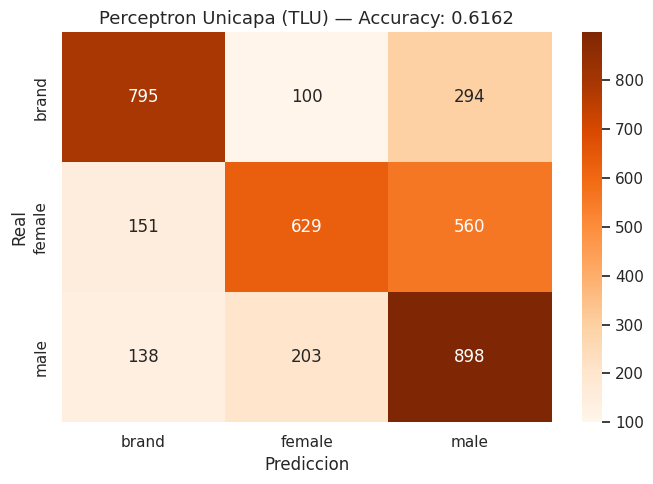

In [20]:
# Matriz de confusion del Perceptron
fig, ax = plt.subplots(figsize=(7, 5))
cm_perc = confusion_matrix(y_test_3, y_pred_perc)
sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Perceptron Unicapa (TLU) — Accuracy: {acc_perc_test:.4f}', fontsize=13)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

## 11. Arquitectura 2: Red Neuronal con 1 Capa Oculta

Red neuronal feedforward con **una capa oculta** cuyo numero de neuronas es igual al numero de entradas (1237). Se usa **ReLU** en la capa oculta y **sigmoid** en la capa de salida.

```
Entrada (1237)  -->  Capa Oculta (1237, ReLU)  -->  Salida (3, Sigmoid)
```

**Funciones de activacion:**
- **ReLU (Rectified Linear Unit):** `f(z) = max(0, z)`. Introduce no-linealidad permitiendo al modelo capturar patrones complejos. Es eficiente y evita el problema del gradiente desvaneciente.
- **Sigmoid:** `f(z) = 1 / (1 + e^(-z))`. Produce salidas entre 0 y 1 interpretables como probabilidades independientes por clase.

**Diferencia con el Perceptron:** Al tener una capa oculta con activacion no-lineal, esta red puede aprender **fronteras de decision no-lineales**, superando la limitacion del perceptron.

In [59]:
# --- Arquitectura 2: 1 capa oculta (n_features neuronas) ---
model_nn1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(n_features, activation='relu', name='hidden_1'),
    layers.Dense(n_classes, activation='sigmoid', name='output'),
], name='NN_1_capa_oculta')

model_nn1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model_nn1.summary()
print(f'\nArquitectura: {n_features} -> {n_features} (ReLU) -> {n_classes} (Sigmoid)')

Model: "NN_1_capa_oculta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 1237)           │     1,531,406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │         3,714 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,535,120 (5.86 MB)

 Trainable params: 1,535,120 (5.86 MB)

 Non-trainable params: 0 (0.00 B)


Arquitectura: 1237 -> 1237 (ReLU) -> 3 (Sigmoid)


In [22]:
# Entrenar NN1
history_nn1 = model_nn1.fit(
    X_train_dense, y_train_oh,
    validation_data=(X_val_dense, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
)

# Evaluar
loss_nn1, acc_nn1_test = model_nn1.evaluate(X_test_dense, y_test_oh, verbose=0)
y_pred_nn1_prob = model_nn1.predict(X_test_dense, verbose=0)
y_pred_nn1 = y_pred_nn1_prob.argmax(axis=1)

print(f'=== RED NEURONAL — 1 CAPA OCULTA ===')
print(f'Arquitectura: {n_features} -> {n_features} (ReLU) -> {n_classes} (Sigmoid)')
print(f'\nAccuracy Test: {accuracy_score(y_test_3, y_pred_nn1):.4f}')
print(f'Loss Test:     {loss_nn1:.4f}\n')
print(classification_report(y_test_3, y_pred_nn1, target_names=le.classes_))

=== RED NEURONAL — 1 CAPA OCULTA ===
Arquitectura: 1237 -> 1237 (ReLU) -> 3 (Sigmoid)

Accuracy Test: 0.6542
Loss Test:     0.8913

              precision    recall  f1-score   support

       brand       0.74      0.72      0.73      1189
      female       0.64      0.65      0.65      1340
        male       0.59      0.59      0.59      1239

    accuracy                           0.65      3768
   macro avg       0.66      0.66      0.66      3768
weighted avg       0.66      0.65      0.65      3768



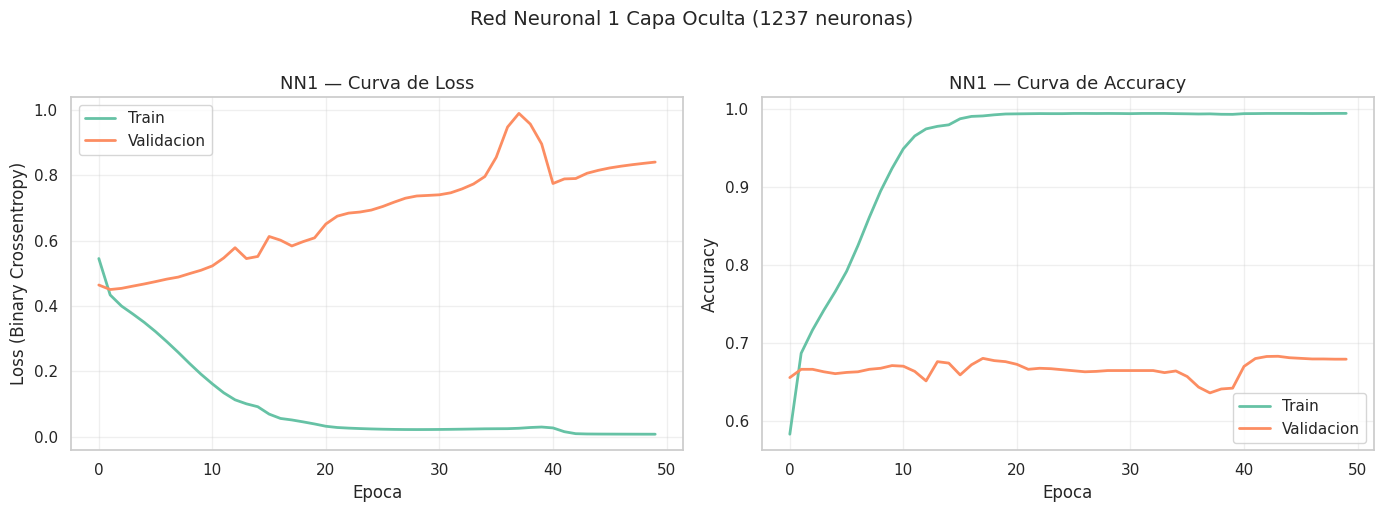

In [23]:
# Curvas de entrenamiento NN1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_nn1.history['loss'], label='Train', linewidth=2)
axes[0].plot(history_nn1.history['val_loss'], label='Validacion', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].set_title('NN1 — Curva de Loss', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_nn1.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history_nn1.history['val_accuracy'], label='Validacion', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('NN1 — Curva de Accuracy', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Red Neuronal 1 Capa Oculta ({n_features} neuronas)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Arquitectura 3: Red Neuronal con 2 Capas Ocultas

Red neuronal feedforward con **dos capas ocultas**:
- **Capa oculta 1:** La mitad del numero de entradas (618 neuronas), activacion **ReLU**.
- **Capa oculta 2:** Misma cantidad que la capa oculta 1 (618 neuronas), activacion **ReLU**.
- **Capa de salida:** 3 neuronas, activacion **Sigmoid**.

```
Entrada (1237) --> Oculta 1 (618, ReLU) --> Oculta 2 (618, ReLU) --> Salida (3, Sigmoid)
```

**Por que 2 capas ocultas?**
- Mayor profundidad permite al modelo aprender **representaciones jerarquicas** de los datos.
- La primera capa puede aprender features de bajo nivel y la segunda combinarlas en patrones mas abstractos.
- Reducir el numero de neuronas (de 1237 a 618) actua como un **cuello de botella** que fuerza a la red a comprimir y extraer las features mas relevantes.

In [24]:
# --- Arquitectura 3: 2 capas ocultas (n_features//2 neuronas cada una) ---
n_hidden = n_features // 2  # 618 neuronas

model_nn2 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(n_hidden, activation='relu', name='hidden_1'),
    layers.Dense(n_hidden, activation='relu', name='hidden_2'),
    layers.Dense(n_classes, activation='sigmoid', name='output'),
], name='NN_2_capas_ocultas')

model_nn2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model_nn2.summary()
print(f'\nArquitectura: {n_features} -> {n_hidden} (ReLU) -> {n_hidden} (ReLU) -> {n_classes} (Sigmoid)')

Model: "NN_2_capas_ocultas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 618)            │       765,084 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 618)            │       382,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │         1,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,149,483 (4.38 MB)

 Trainable params: 1,149,483 (4.38 MB)

 Non-trainable params: 0 (0.00 B)


Arquitectura: 1237 -> 618 (ReLU) -> 618 (ReLU) -> 3 (Sigmoid)


In [ ]:
# Entrenar NN2
history_nn2 = model_nn2.fit(
    X_train_dense, y_train_oh,
    validation_data=(X_val_dense, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
)

# Evaluar
loss_nn2, acc_nn2_test = model_nn2.evaluate(X_test_dense, y_test_oh, verbose=0)
y_pred_nn2_prob = model_nn2.predict(X_test_dense, verbose=0)
y_pred_nn2 = y_pred_nn2_prob.argmax(axis=1)

print(f'=== RED NEURONAL — 2 CAPAS OCULTAS ===')
print(f'Arquitectura: {n_features} -> {n_hidden} (ReLU) -> {n_hidden} (ReLU) -> {n_classes} (Sigmoid)')
print(f'\nAccuracy Test: {accuracy_score(y_test_3, y_pred_nn2):.4f}')
print(f'Loss Test:     {loss_nn2:.4f}\n')
print(classification_report(y_test_3, y_pred_nn2, target_names=le.classes_))

KeyboardInterrupt: 

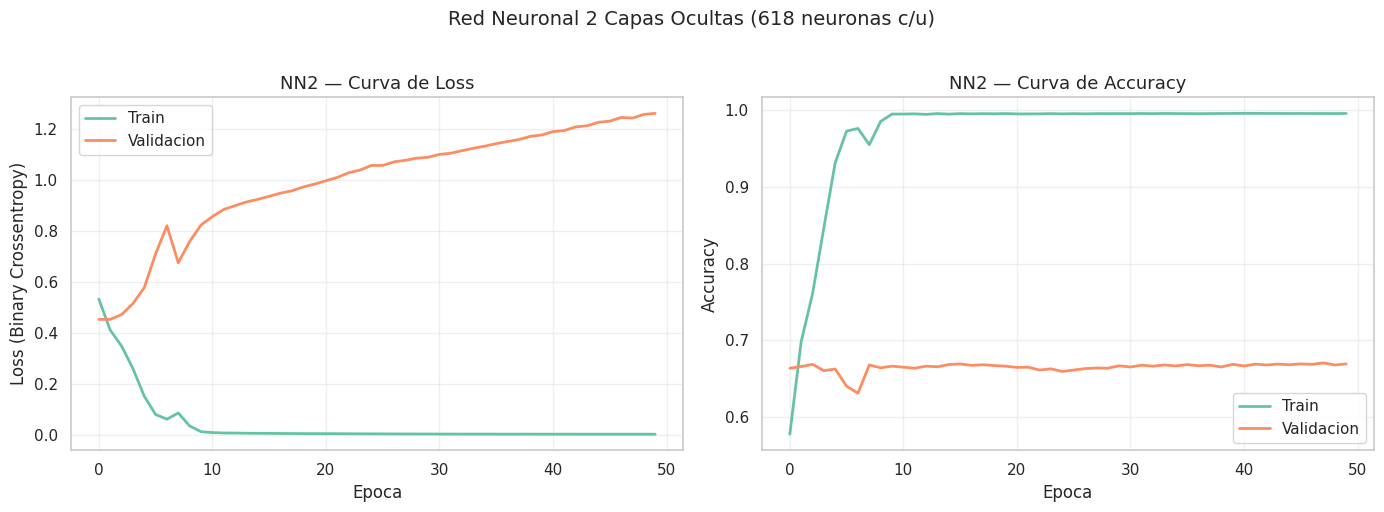

In [ ]:
# Curvas de entrenamiento NN2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_nn2.history['loss'], label='Train', linewidth=2)
axes[0].plot(history_nn2.history['val_loss'], label='Validacion', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].set_title('NN2 — Curva de Loss', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_nn2.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history_nn2.history['val_accuracy'], label='Validacion', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('NN2 — Curva de Accuracy', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Red Neuronal 2 Capas Ocultas ({n_hidden} neuronas c/u)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. Comparacion de Arquitecturas

In [27]:
# Accuracy comparable con sklearn (usando argmax sobre las probabilidades)
acc_nn1_sk = accuracy_score(y_test_3, y_pred_nn1)
acc_nn2_sk = accuracy_score(y_test_3, y_pred_nn2)

# Tabla comparativa de todas las arquitecturas
print('=' * 90)
print(f'{"COMPARACION DE ARQUITECTURAS":^90}')
print('=' * 90)
print(f'{"Modelo":<35} {"Capas":<20} {"Activacion":<18} {"Acc Test":>10}')
print('-' * 90)
print(f'{"Logistic Regression (ref.)":35} {"1 (lineal)":20} {"softmax":18} {acc_test_3:>10.4f}')
print(f'{"Perceptron unicapa (TLU)":35} {"1 (lineal)":20} {"escalon (step)":18} {acc_perc_test:>10.4f}')
print(f'{"NN 1 capa oculta":35} {f"2 ({n_features}->{n_classes})":20} {"ReLU + Sigmoid":18} {acc_nn1_sk:>10.4f}')
print(f'{"NN 2 capas ocultas":35} {f"3 ({n_features//2}->{n_features//2}->{n_classes})":20} {"ReLU + Sigmoid":18} {acc_nn2_sk:>10.4f}')
print('=' * 90)

                               COMPARACION DE ARQUITECTURAS                               
Modelo                              Capas                Activacion           Acc Test
------------------------------------------------------------------------------------------
Logistic Regression (ref.)          1 (lineal)           softmax                0.6542
Perceptron unicapa (TLU)            1 (lineal)           escalon (step)         0.6162
NN 1 capa oculta                    2 (1237->3)          ReLU + Sigmoid         0.6542
NN 2 capas ocultas                  3 (618->618->3)      ReLU + Sigmoid         0.6499


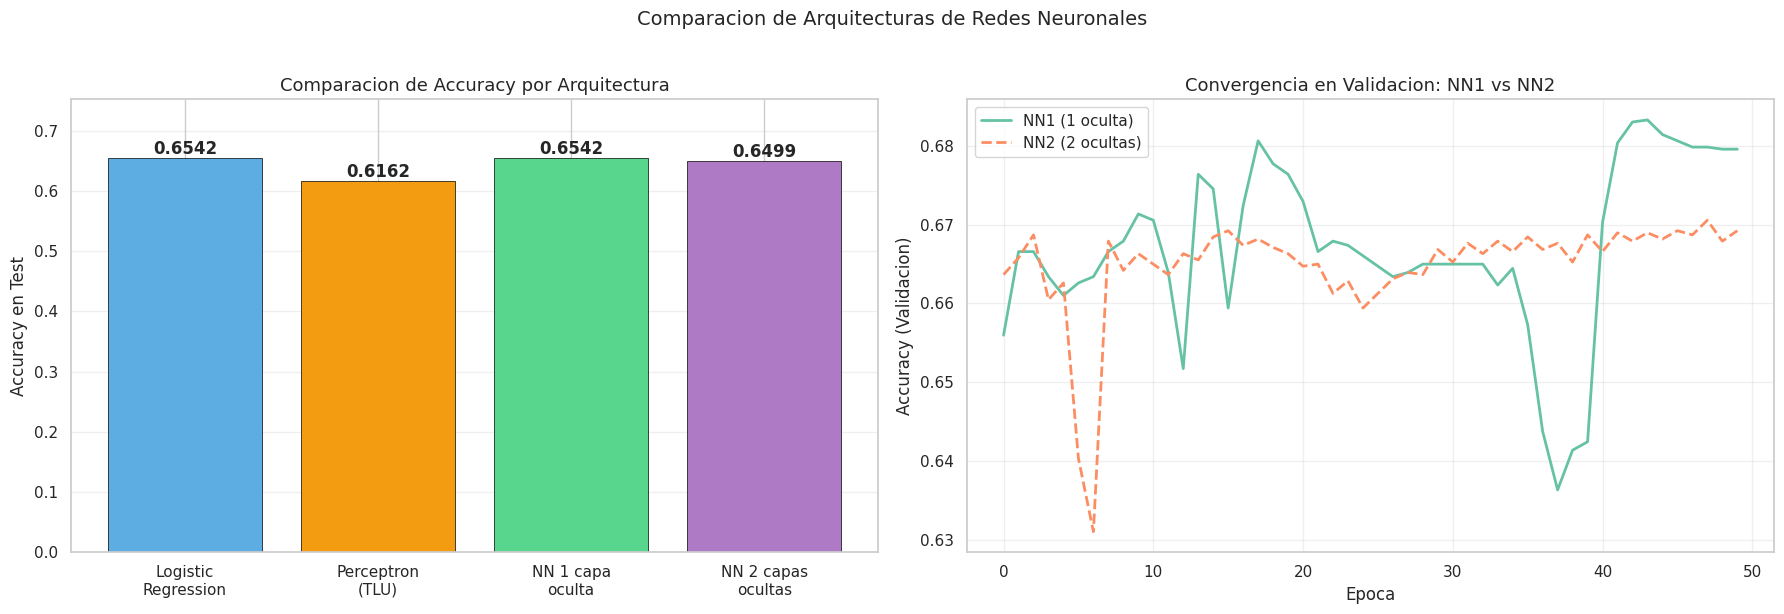

In [28]:
# Grafico comparativo de accuracy
acc_nn1_sk = accuracy_score(y_test_3, y_pred_nn1)
acc_nn2_sk = accuracy_score(y_test_3, y_pred_nn2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Barras de accuracy ---
modelos = ['Logistic\nRegression', 'Perceptron\n(TLU)', 'NN 1 capa\noculta', 'NN 2 capas\nocultas']
accs = [acc_test_3, acc_perc_test, acc_nn1_sk, acc_nn2_sk]
colors_bar = ['#5DADE2', '#F39C12', '#58D68D', '#AF7AC5']

bars = axes[0].bar(modelos, accs, color=colors_bar, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    axes[0].annotate(f'{acc:.4f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy en Test', fontsize=12)
axes[0].set_title('Comparacion de Accuracy por Arquitectura', fontsize=13)
axes[0].set_ylim(0, max(accs) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# --- Curvas de validacion NN1 vs NN2 ---
axes[1].plot(history_nn1.history['val_accuracy'], label='NN1 (1 oculta)', linewidth=2)
axes[1].plot(history_nn2.history['val_accuracy'], label='NN2 (2 ocultas)', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy (Validacion)')
axes[1].set_title('Convergencia en Validacion: NN1 vs NN2', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion de Arquitecturas de Redes Neuronales', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

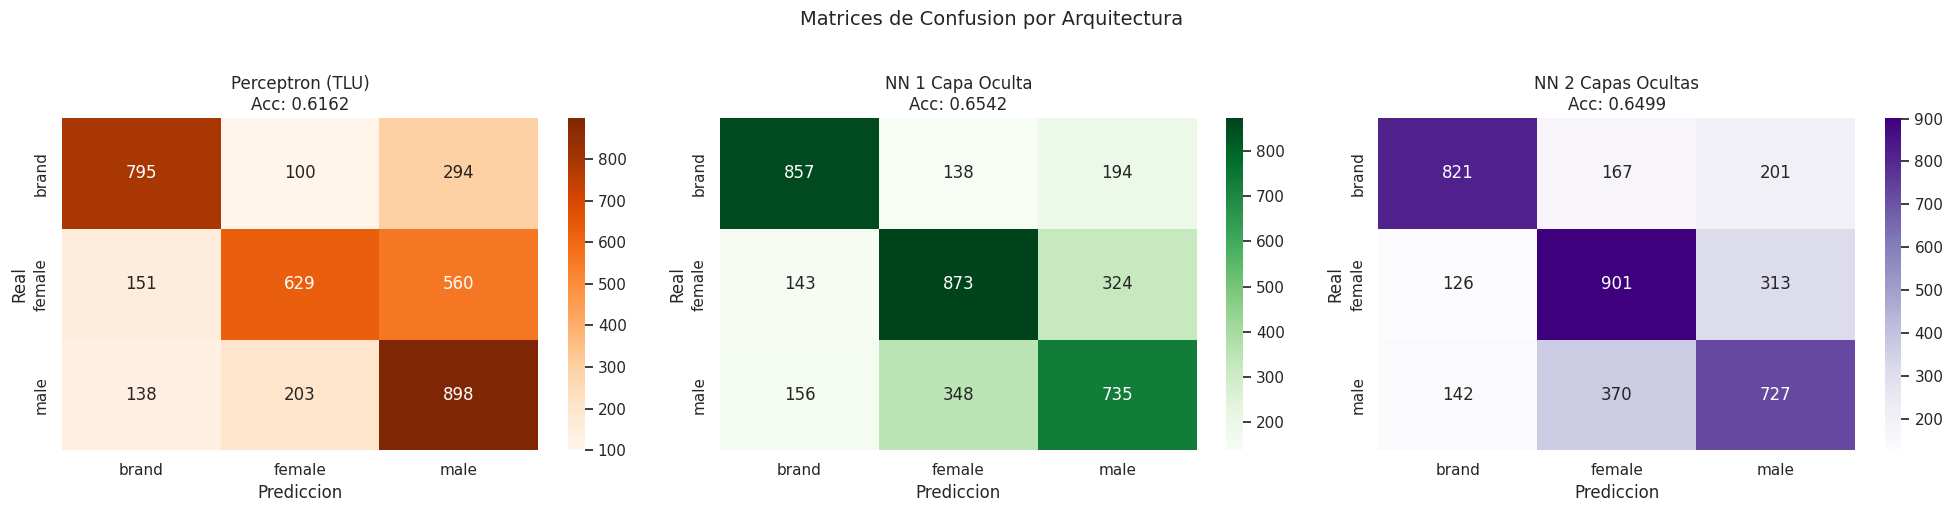

In [29]:
# Matrices de confusion de las 3 arquitecturas
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cms = [
    (cm_perc, f'Perceptron (TLU)\nAcc: {acc_perc_test:.4f}', 'Oranges'),
    (confusion_matrix(y_test_3, y_pred_nn1), f'NN 1 Capa Oculta\nAcc: {acc_nn1_sk:.4f}', 'Greens'),
    (confusion_matrix(y_test_3, y_pred_nn2), f'NN 2 Capas Ocultas\nAcc: {acc_nn2_sk:.4f}', 'Purples'),
]

for ax, (cm_data, title, cmap) in zip(axes, cms):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusion por Arquitectura', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Conclusiones — Elaboracion del Modelo

### Resumen de arquitecturas

| Arquitectura | Capas | Neuronas | Activacion | Complejidad |
|---|---|---|---|---|
| **Perceptron (TLU)** | 1 (entrada->salida) | 1237->3 | Escalon (step) | Muy baja |
| **NN 1 capa oculta** | 2 (oculta + salida) | 1237->1237->3 | ReLU + Sigmoid | Alta (~1.5M params) |
| **NN 2 capas ocultas** | 3 (2 ocultas + salida) | 1237->618->618->3 | ReLU + ReLU + Sigmoid | Media (~1.1M params) |

### Analisis por arquitectura

1. **Perceptron (TLU):** Es el modelo mas simple. Al usar la funcion escalon, solo puede trazar fronteras de decision **lineales**. Su rendimiento es limitado porque el problema de clasificacion de genero tiene relaciones no-lineales entre las features.

2. **NN 1 capa oculta (ReLU + Sigmoid):** Al introducir una capa oculta con ReLU, la red puede modelar **relaciones no-lineales**. La capa de 1237 neuronas tiene la misma dimensionalidad que la entrada, lo que le da gran capacidad expresiva pero tambien riesgo de overfitting.

3. **NN 2 capas ocultas (ReLU + ReLU + Sigmoid):** La mayor profundidad permite aprender **representaciones jerarquicas**. El cuello de botella (618 neuronas vs 1237 de entrada) fuerza una compresion de la informacion, lo que puede actuar como regularizacion implicita.

### Funciones de activacion utilizadas

- **Escalon (TLU):** No es diferenciable, no permite backpropagation. El perceptron usa una regla de aprendizaje propia basada en la correccion de errores. Produce salidas binarias discretas (0/1).
- **ReLU:** `f(z) = max(0, z)`. Diferenciable (excepto en z=0), eficiente computacionalmente, evita el problema del gradiente desvaneciente. Ideal para capas ocultas.
- **Sigmoid:** `f(z) = 1 / (1 + e^(-z))`. Mapea la salida al rango [0, 1]. En la capa de salida, cada neurona produce una probabilidad independiente por clase.

# 7) Analisis de Resultados

**Objetivo:** Construir las matrices de confusion y calcular las metricas de evaluacion (Accuracy, Precision, Recall, F1-Score) para cada uno de los 4 modelos entrenados. Luego realizar un analisis comparativo detallado de los resultados.

**Modelos evaluados:**
1. Logistic Regression (referencia)
2. Perceptron unicapa (TLU)
3. Red neuronal con 1 capa oculta (ReLU + Sigmoid)
4. Red neuronal con 2 capas ocultas (ReLU + Sigmoid)

## 15. Matrices de Confusion

La matriz de confusion muestra, para cada clase real, cuantos registros fueron clasificados en cada clase predicha. Permite identificar:
- **Diagonal principal:** Predicciones correctas.
- **Fuera de la diagonal:** Errores de clasificacion y patrones de confusion entre clases.

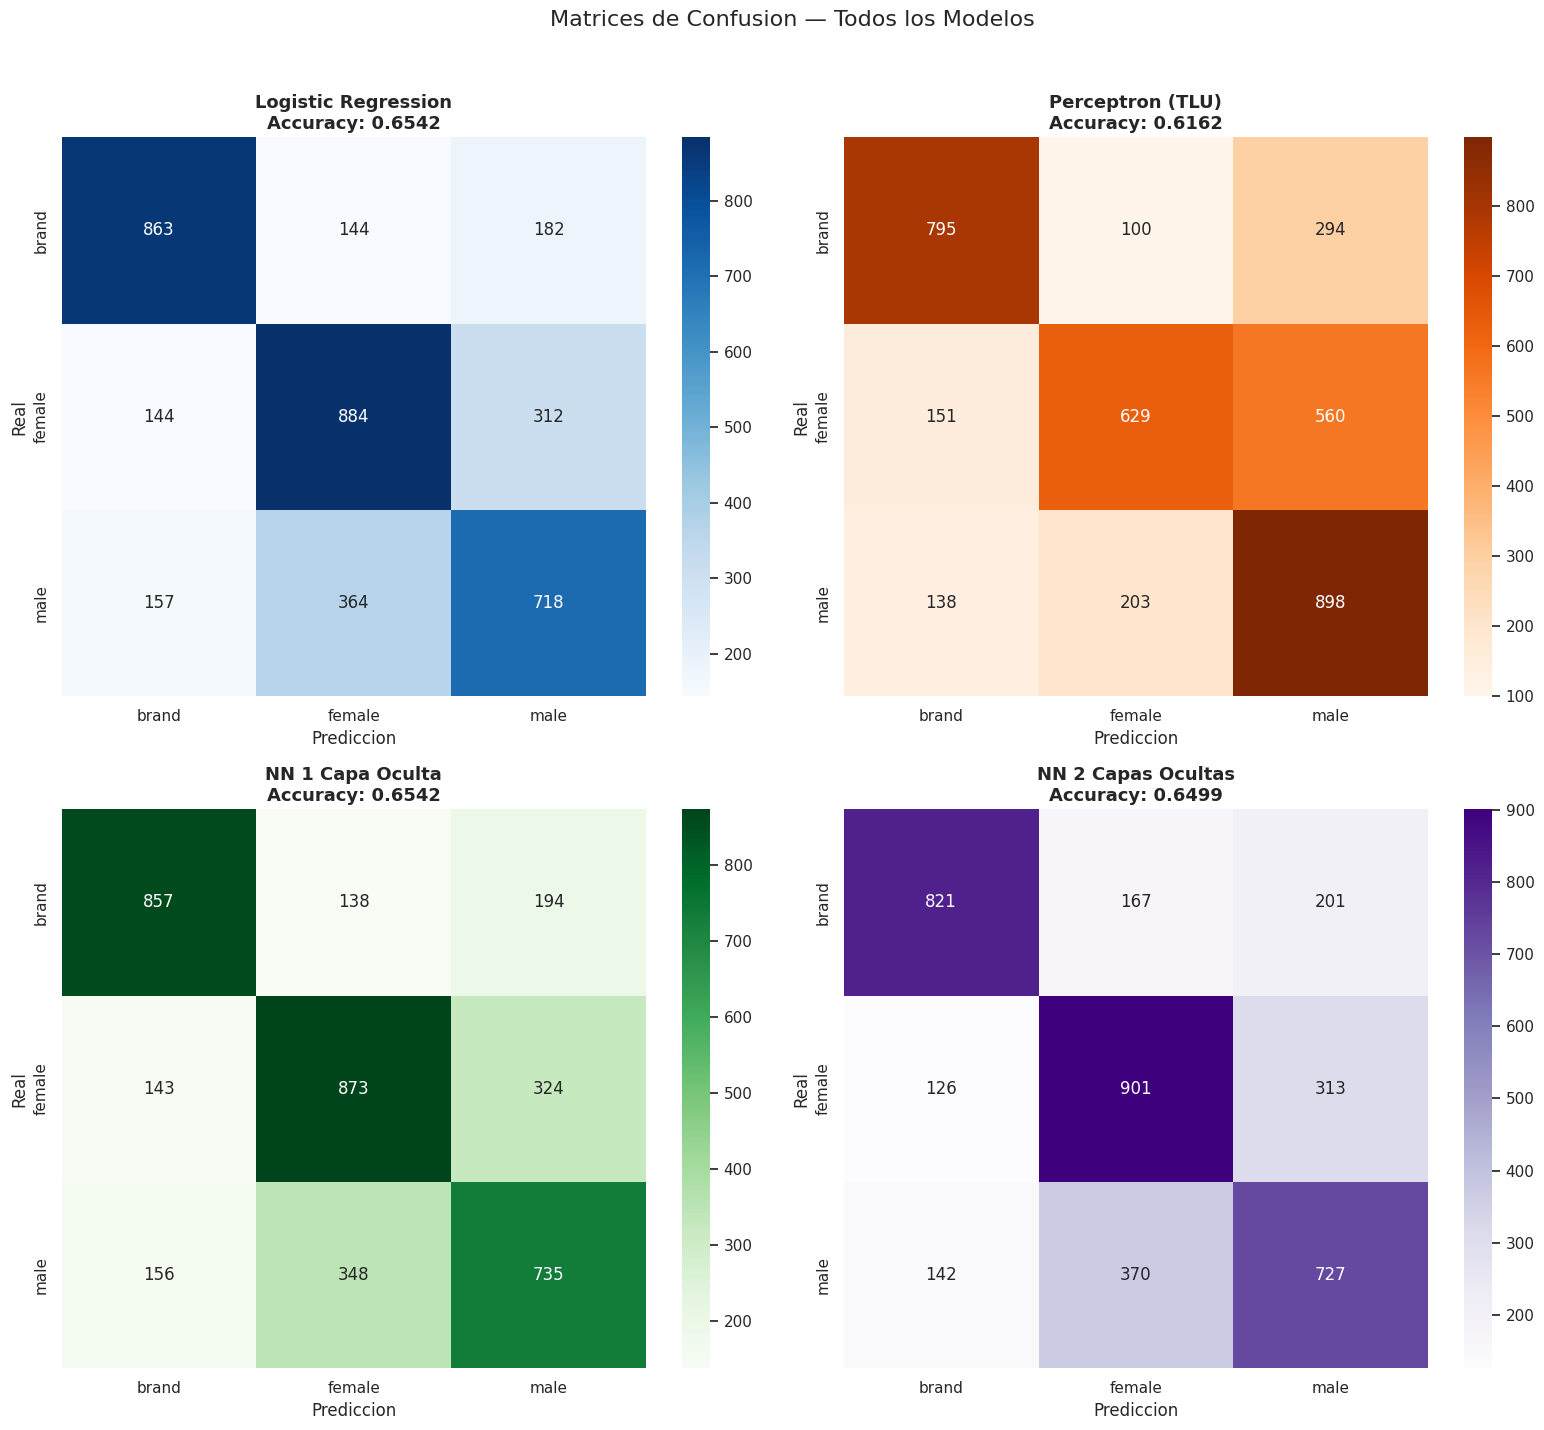

In [30]:
# Calcular todas las matrices de confusion y predicciones
modelos_info = {
    'Logistic Regression': {'y_pred': y_pred_3, 'color': 'Blues'},
    'Perceptron (TLU)':    {'y_pred': y_pred_perc, 'color': 'Oranges'},
    'NN 1 Capa Oculta':    {'y_pred': y_pred_nn1, 'color': 'Greens'},
    'NN 2 Capas Ocultas':  {'y_pred': y_pred_nn2, 'color': 'Purples'},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (nombre, info) in zip(axes, modelos_info.items()):
    cm = confusion_matrix(y_test_3, info['y_pred'])
    acc = accuracy_score(y_test_3, info['y_pred'])
    info['cm'] = cm  # guardar para uso posterior
    
    # Matriz con valores absolutos
    sns.heatmap(cm, annot=True, fmt='d', cmap=info['color'],
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{nombre}\nAccuracy: {acc:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusion — Todos los Modelos', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

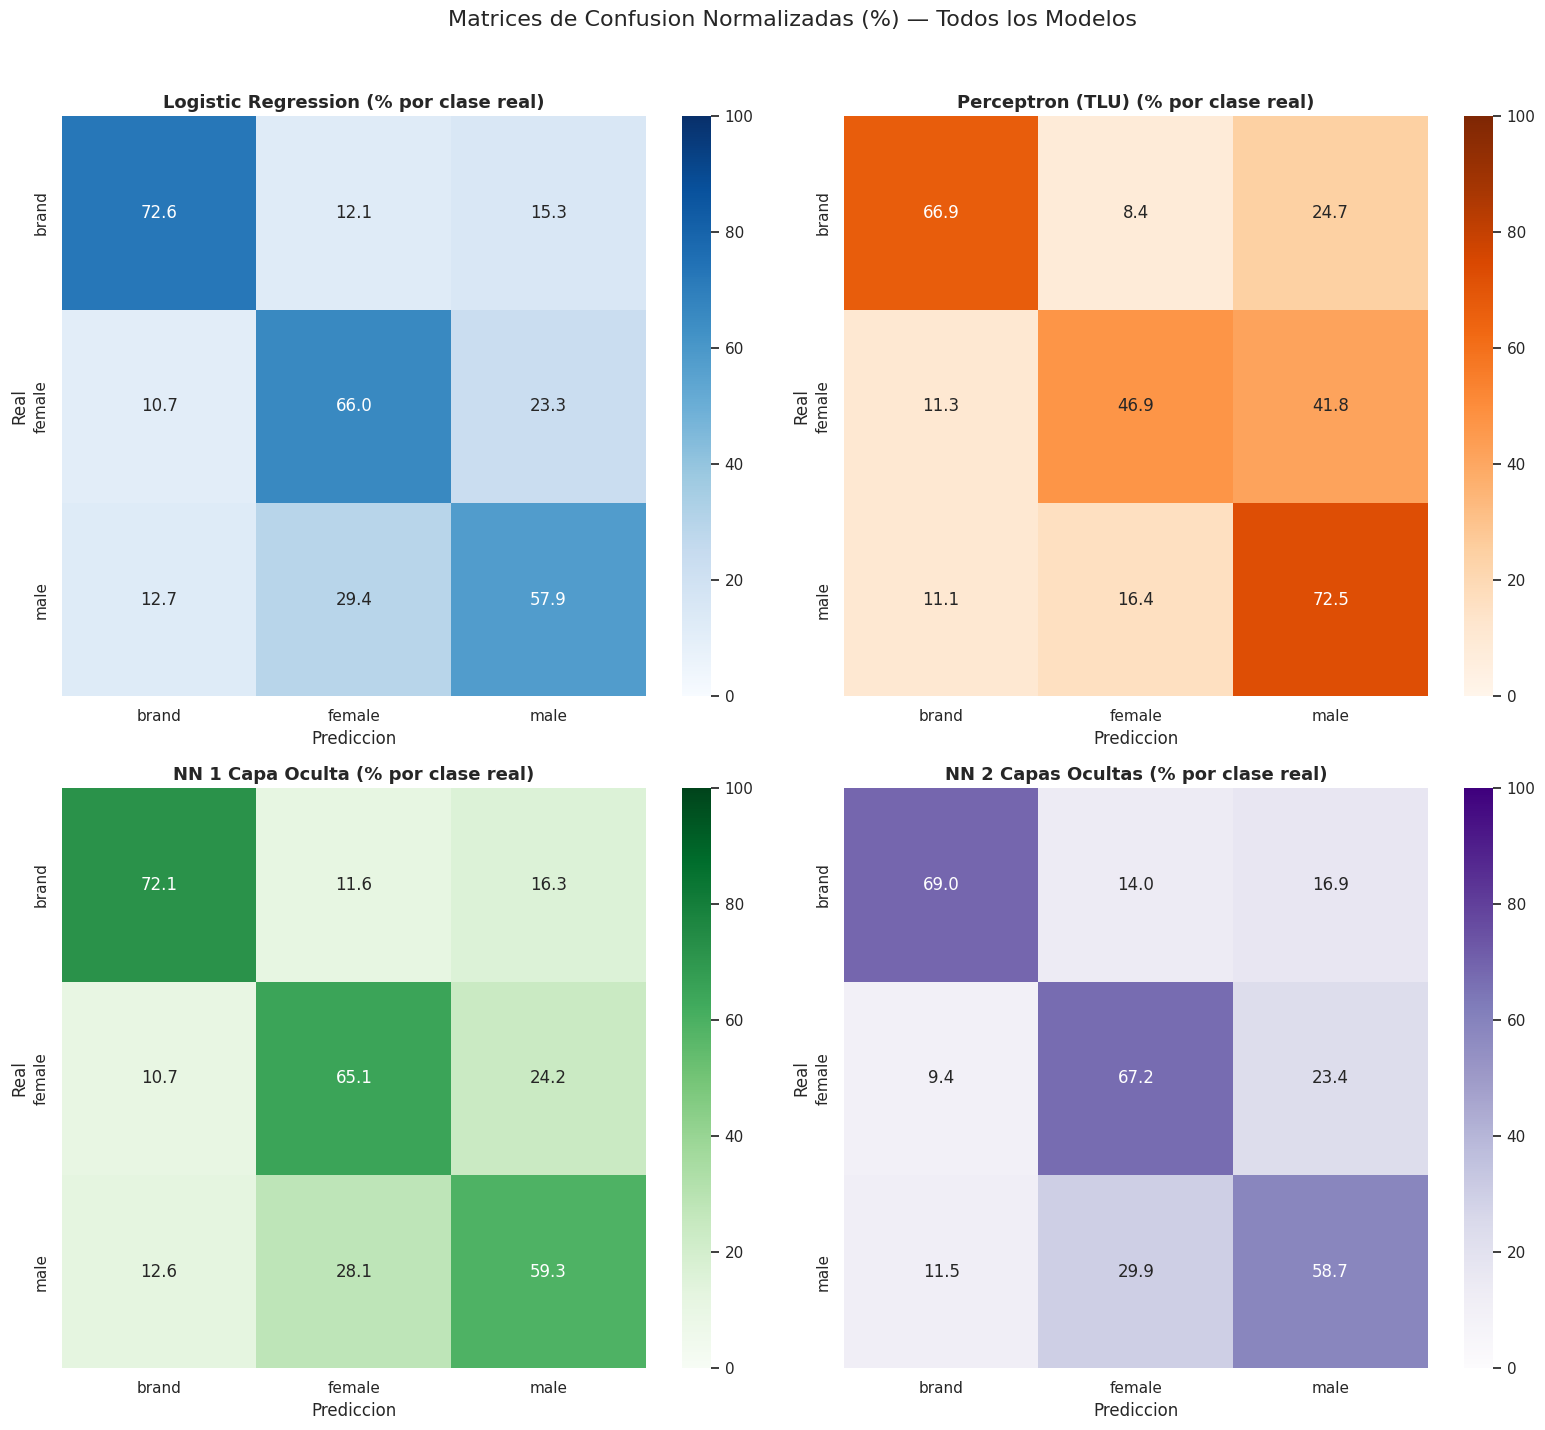

In [31]:
# Matrices de confusion NORMALIZADAS (porcentaje por clase real)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (nombre, info) in zip(axes, modelos_info.items()):
    cm = info['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap=info['color'],
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
                vmin=0, vmax=100)
    ax.set_title(f'{nombre} (% por clase real)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusion Normalizadas (%) — Todos los Modelos', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 16. Metricas de Evaluacion por Modelo

Se calculan las siguientes metricas para cada modelo:

- **Accuracy:** Proporcion de predicciones correctas sobre el total. Metrica global.
- **Precision:** De todas las predicciones de una clase, que porcentaje fue correcto. Responde: *"Cuando el modelo dice 'female', que tan seguido acierta?"*
- **Recall:** De todos los ejemplos reales de una clase, que porcentaje fue detectado. Responde: *"De todas las 'female' reales, cuantas encontro el modelo?"*
- **F1-Score:** Media armonica de Precision y Recall. Balancea ambas metricas en un solo numero.

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calcular metricas detalladas para cada modelo
resultados = []

for nombre, info in modelos_info.items():
    y_pred = info['y_pred']
    
    # Metricas por clase
    p, r, f1, sup = precision_recall_fscore_support(y_test_3, y_pred)
    acc = accuracy_score(y_test_3, y_pred)
    
    # Metricas globales (macro = promedio sin ponderar)
    p_macro = precision_score(y_test_3, y_pred, average='macro')
    r_macro = recall_score(y_test_3, y_pred, average='macro')
    f1_macro = f1_score(y_test_3, y_pred, average='macro')
    
    info['metrics'] = {
        'accuracy': acc,
        'precision_per_class': p,
        'recall_per_class': r,
        'f1_per_class': f1,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro,
        'support': sup,
    }
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision (macro)': p_macro,
        'Recall (macro)': r_macro,
        'F1-Score (macro)': f1_macro,
    })

# Tabla resumen
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('=' * 80)
print(f'{"METRICAS GLOBALES POR MODELO":^80}')
print('=' * 80)
print(df_resultados.to_string(float_format='{:.4f}'.format))
print('=' * 80)
print()
print(f'Mejor modelo por Accuracy:  {df_resultados["Accuracy"].idxmax()} ({df_resultados["Accuracy"].max():.4f})')
print(f'Mejor modelo por F1-Score:  {df_resultados["F1-Score (macro)"].idxmax()} ({df_resultados["F1-Score (macro)"].max():.4f})')

                          METRICAS GLOBALES POR MODELO                          
                     Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Modelo                                                                            
Logistic Regression    0.6542             0.6563          0.6550            0.6555
Perceptron (TLU)       0.6162             0.6403          0.6209            0.6179
NN 1 Capa Oculta       0.6542             0.6568          0.6552            0.6559
NN 2 Capas Ocultas     0.6499             0.6554          0.6499            0.6519

Mejor modelo por Accuracy:  Logistic Regression (0.6542)
Mejor modelo por F1-Score:  NN 1 Capa Oculta (0.6559)


In [33]:
# Metricas detalladas POR CLASE para cada modelo
for nombre, info in modelos_info.items():
    m = info['metrics']
    print(f'\n{"=" * 65}')
    print(f'{nombre:^65}')
    print(f'{"=" * 65}')
    print(f'{"Clase":<12} {"Precision":>12} {"Recall":>12} {"F1-Score":>12} {"Soporte":>12}')
    print(f'{"-" * 65}')
    for j, clase in enumerate(le.classes_):
        print(f'{clase:<12} {m["precision_per_class"][j]:>12.4f} {m["recall_per_class"][j]:>12.4f} '
              f'{m["f1_per_class"][j]:>12.4f} {m["support"][j]:>12}')
    print(f'{"-" * 65}')
    print(f'{"PROMEDIO":<12} {m["precision_macro"]:>12.4f} {m["recall_macro"]:>12.4f} '
          f'{m["f1_macro"]:>12.4f} {sum(m["support"]):>12}')
    print(f'{"Accuracy":<12} {"":>12} {"":>12} {m["accuracy"]:>12.4f}')


                       Logistic Regression                       
Clase           Precision       Recall     F1-Score      Soporte
-----------------------------------------------------------------
brand              0.7414       0.7258       0.7335         1189
female             0.6351       0.6597       0.6471         1340
male               0.5924       0.5795       0.5859         1239
-----------------------------------------------------------------
PROMEDIO           0.6563       0.6550       0.6555         3768
Accuracy                                     0.6542

                        Perceptron (TLU)                         
Clase           Precision       Recall     F1-Score      Soporte
-----------------------------------------------------------------
brand              0.7334       0.6686       0.6995         1189
female             0.6749       0.4694       0.5537         1340
male               0.5126       0.7248       0.6005         1239
-------------------------------

## 17. Analisis Comparativo Visual

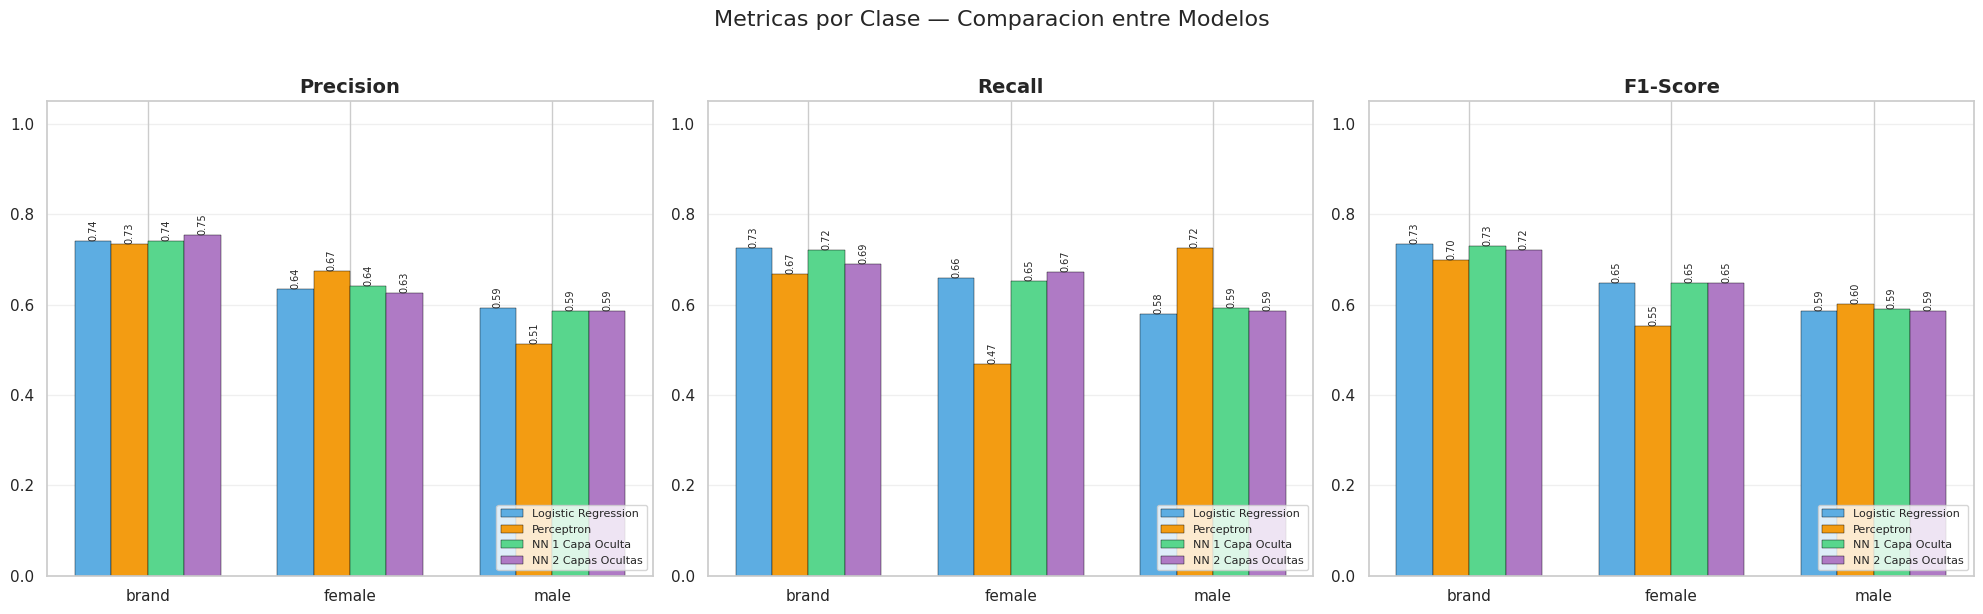

In [34]:
# Grafico comparativo: Metricas por clase para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_names = list(modelos_info.keys())
n_models = len(model_names)
x = np.arange(len(le.classes_))
width = 0.18
colors_models = ['#5DADE2', '#F39C12', '#58D68D', '#AF7AC5']

metric_data = [
    ('Precision', 'precision_per_class'),
    ('Recall', 'recall_per_class'),
    ('F1-Score', 'f1_per_class'),
]

for ax, (metric_name, metric_key) in zip(axes, metric_data):
    for i, (nombre, info) in enumerate(modelos_info.items()):
        values = info['metrics'][metric_key]
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, values, width, label=nombre.split('(')[0].strip(),
                      color=colors_models[i], edgecolor='black', linewidth=0.3)
        for bar in bars:
            ax.annotate(f'{bar.get_height():.2f}',
                       (bar.get_x() + bar.get_width()/2, bar.get_height()),
                       ha='center', va='bottom', fontsize=7, rotation=90)
    
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(le.classes_, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Metricas por Clase — Comparacion entre Modelos', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

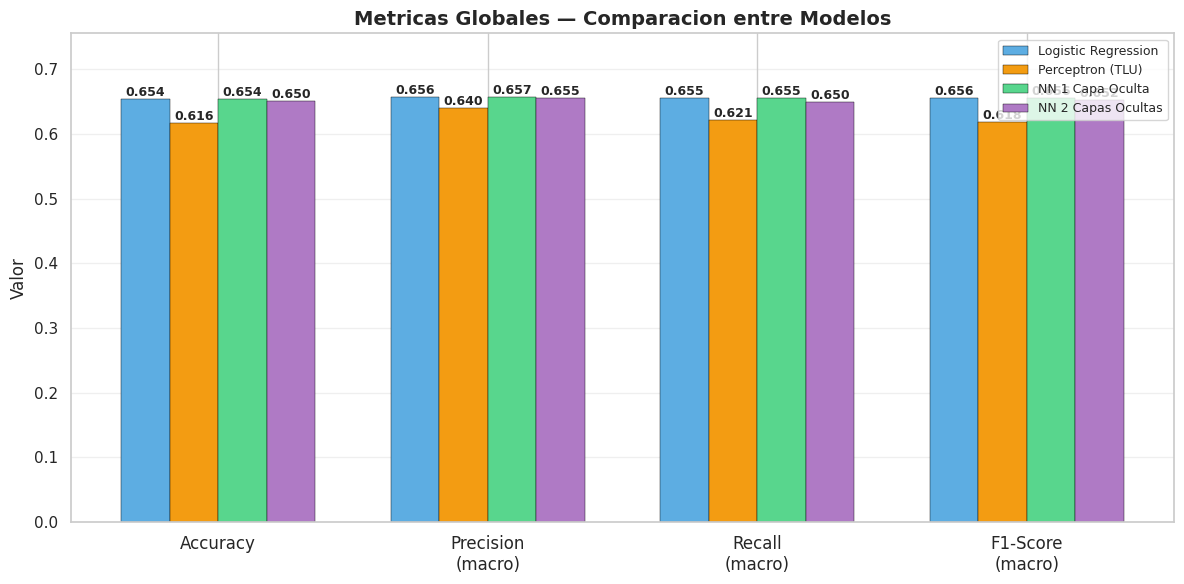

In [35]:
# Comparacion de metricas globales (macro-promedio)
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1-Score\n(macro)']
x = np.arange(len(metrics_names))
width = 0.18

for i, (nombre, info) in enumerate(modelos_info.items()):
    m = info['metrics']
    values = [m['accuracy'], m['precision_macro'], m['recall_macro'], m['f1_macro']]
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=nombre,
                  color=colors_models[i], edgecolor='black', linewidth=0.3)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                   (bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, max(df_resultados.max()) * 1.15)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Metricas Globales — Comparacion entre Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

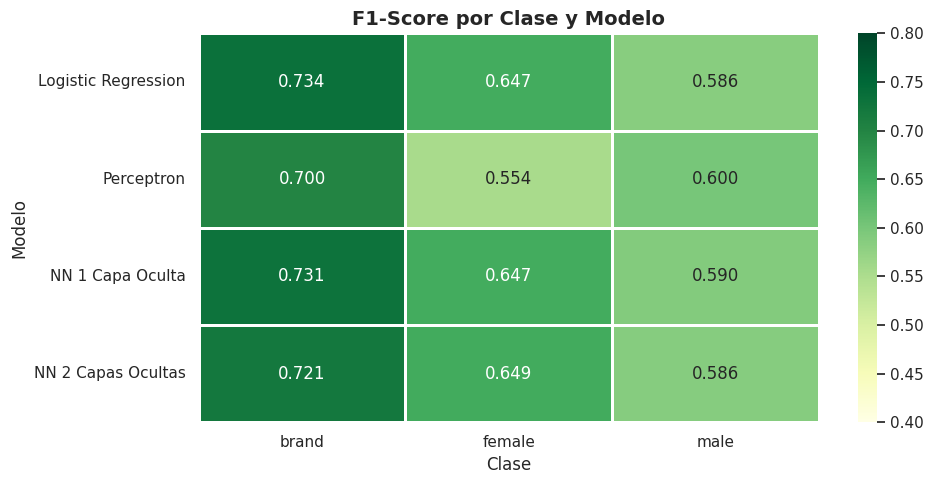


F1-Score detallado:
                      brand  female    male
Logistic Regression  0.7335  0.6471  0.5859
Perceptron           0.6995  0.5537  0.6005
NN 1 Capa Oculta     0.7309  0.6469  0.5899
NN 2 Capas Ocultas   0.7208  0.6487  0.5863


In [36]:
# Heatmap resumen: F1-Score por clase y modelo
f1_data = {}
for nombre, info in modelos_info.items():
    short_name = nombre.split('(')[0].strip()
    f1_data[short_name] = dict(zip(le.classes_, info['metrics']['f1_per_class']))

df_f1 = pd.DataFrame(f1_data).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_f1, annot=True, fmt='.3f', cmap='YlGn', 
            linewidths=1, linecolor='white', ax=ax,
            vmin=0.4, vmax=0.8)
ax.set_title('F1-Score por Clase y Modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('Modelo')
ax.set_xlabel('Clase')
plt.tight_layout()
plt.show()

print('\nF1-Score detallado:')
print(df_f1.round(4).to_string())

## 18. Analisis de Errores por Modelo

In [37]:
# Analisis de errores: que pares de clases se confunden mas
print('=== PRINCIPALES CONFUSIONES POR MODELO ===\n')

for nombre, info in modelos_info.items():
    cm = info['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    print(f'{nombre}:')
    # Encontrar los mayores errores (fuera de diagonal)
    errores = []
    for i in range(len(le.classes_)):
        for j in range(len(le.classes_)):
            if i != j:
                errores.append({
                    'real': le.classes_[i],
                    'pred': le.classes_[j],
                    'count': cm[i, j],
                    'pct': cm_norm[i, j],
                })
    errores.sort(key=lambda x: x['count'], reverse=True)
    for e in errores[:3]:  # Top 3 confusiones
        print(f'  {e["real"]:>8} confundido con {e["pred"]:<8}: '
              f'{e["count"]:>4} casos ({e["pct"]:.1f}%)')
    print()

=== PRINCIPALES CONFUSIONES POR MODELO ===

Logistic Regression:
      male confundido con female  :  364 casos (29.4%)
    female confundido con male    :  312 casos (23.3%)
     brand confundido con male    :  182 casos (15.3%)

Perceptron (TLU):
    female confundido con male    :  560 casos (41.8%)
     brand confundido con male    :  294 casos (24.7%)
      male confundido con female  :  203 casos (16.4%)

NN 1 Capa Oculta:
      male confundido con female  :  348 casos (28.1%)
    female confundido con male    :  324 casos (24.2%)
     brand confundido con male    :  194 casos (16.3%)

NN 2 Capas Ocultas:
      male confundido con female  :  370 casos (29.9%)
    female confundido con male    :  313 casos (23.4%)
     brand confundido con male    :  201 casos (16.9%)



In [38]:
# Analisis especifico: Rendimiento en la clase 'brand'
# (separar marcas de personas es un reto distinto a distinguir genero)
print('=== RENDIMIENTO EN DETECCION DE BRAND ===\n')
print(f'{"Modelo":<25} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 58)
brand_idx = list(le.classes_).index('brand')
for nombre, info in modelos_info.items():
    m = info['metrics']
    print(f'{nombre:<25} {m["precision_per_class"][brand_idx]:>10.4f} '
          f'{m["recall_per_class"][brand_idx]:>10.4f} '
          f'{m["f1_per_class"][brand_idx]:>10.4f}')

print('\n=== RENDIMIENTO EN CLASIFICACION DE GENERO (male vs female) ===\n')
print(f'{"Modelo":<25} {"":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 68)
for nombre, info in modelos_info.items():
    m = info['metrics']
    for clase in ['female', 'male']:
        idx = list(le.classes_).index(clase)
        lbl = f'{nombre}' if clase == 'female' else ''
        print(f'{lbl:<25} {clase:>10} {m["precision_per_class"][idx]:>10.4f} '
              f'{m["recall_per_class"][idx]:>10.4f} '
              f'{m["f1_per_class"][idx]:>10.4f}')

=== RENDIMIENTO EN DETECCION DE BRAND ===

Modelo                     Precision     Recall         F1
----------------------------------------------------------
Logistic Regression           0.7414     0.7258     0.7335
Perceptron (TLU)              0.7334     0.6686     0.6995
NN 1 Capa Oculta              0.7413     0.7208     0.7309
NN 2 Capas Ocultas            0.7539     0.6905     0.7208

=== RENDIMIENTO EN CLASIFICACION DE GENERO (male vs female) ===

Modelo                                Precision     Recall         F1
--------------------------------------------------------------------
Logistic Regression           female     0.6351     0.6597     0.6471
                                male     0.5924     0.5795     0.5859
Perceptron (TLU)              female     0.6749     0.4694     0.5537
                                male     0.5126     0.7248     0.6005
NN 1 Capa Oculta              female     0.6424     0.6515     0.6469
                                male     0.5866 

                       RANKING FINAL DE MODELOS                       
  #1 NN 1 Capa Oculta          Acc=0.6542  P=0.6568  R=0.6552  F1=0.6559 <-- MEJOR
  #2 Logistic Regression       Acc=0.6542  P=0.6563  R=0.6550  F1=0.6555
  #3 NN 2 Capas Ocultas        Acc=0.6499  P=0.6554  R=0.6499  F1=0.6519
  #4 Perceptron (TLU)          Acc=0.6162  P=0.6403  R=0.6209  F1=0.6179


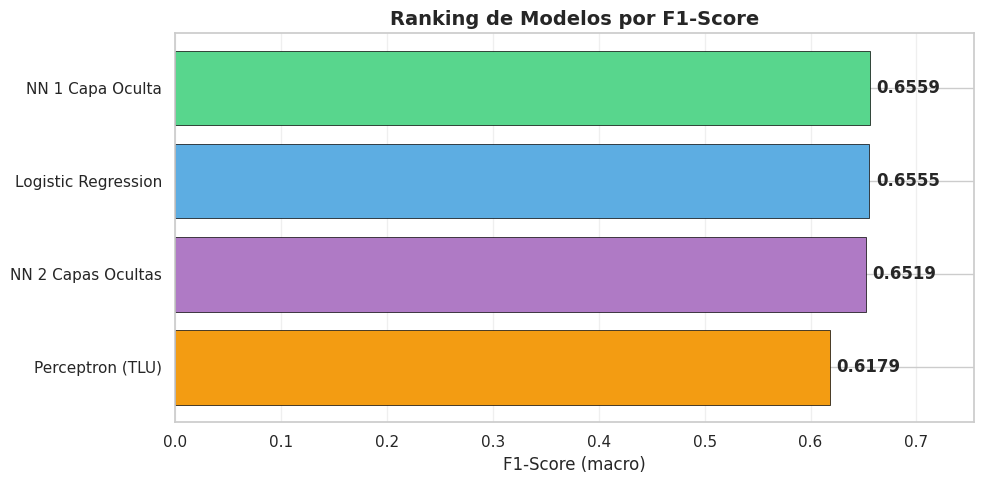

In [39]:
# Ranking final de modelos
print('=' * 70)
print(f'{"RANKING FINAL DE MODELOS":^70}')
print('=' * 70)

df_rank = df_resultados.copy()
df_rank['Ranking'] = df_rank['F1-Score (macro)'].rank(ascending=False).astype(int)
df_rank = df_rank.sort_values('Ranking')

for _, row in df_rank.iterrows():
    marca = ' <-- MEJOR' if row['Ranking'] == 1 else ''
    print(f'  #{int(row["Ranking"])} {row.name:<25} '
          f'Acc={row["Accuracy"]:.4f}  '
          f'P={row["Precision (macro)"]:.4f}  '
          f'R={row["Recall (macro)"]:.4f}  '
          f'F1={row["F1-Score (macro)"]:.4f}{marca}')

print('=' * 70)

# Grafico de ranking
fig, ax = plt.subplots(figsize=(10, 5))
df_sorted = df_resultados.sort_values('F1-Score (macro)', ascending=True)
colors_rank = [colors_models[model_names.index(m)] for m in df_sorted.index]

bars = ax.barh(range(len(df_sorted)), df_sorted['F1-Score (macro)'],
               color=colors_rank, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted.index, fontsize=11)
ax.set_xlabel('F1-Score (macro)', fontsize=12)
ax.set_title('Ranking de Modelos por F1-Score', fontsize=14, fontweight='bold')

for bar in bars:
    ax.annotate(f'{bar.get_width():.4f}',
               (bar.get_width(), bar.get_y() + bar.get_height()/2),
               ha='left', va='center', fontsize=12, fontweight='bold',
               xytext=(5, 0), textcoords='offset points')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, df_sorted['F1-Score (macro)'].max() * 1.15)
plt.tight_layout()
plt.show()

## 19. Conclusiones del Analisis de Resultados

### Hallazgos principales

**1. La clase `brand` es la mas facil de clasificar:**
- Todos los modelos obtienen la mayor precision y F1-Score en esta clase.
- Esto tiene sentido: las cuentas de marca tienen patrones de texto, nombres y comportamiento muy distintos a las cuentas personales.

**2. La distincion `male` vs `female` es el mayor reto:**
- La clase `male` tiene consistentemente el peor recall y F1-Score en todos los modelos.
- Existe confusion significativa entre `male` y `female`, lo cual es esperable ya que los patrones linguisticos y de comportamiento entre generos son mas sutiles que entre personas y marcas.

**3. El Perceptron (TLU) tiene el peor rendimiento:**
- Su limitacion a fronteras de decision lineales con funcion escalon no le permite capturar las relaciones complejas del problema.
- Tiene un recall muy desbalanceado entre clases, lo que indica que la funcion escalon genera fronteras de decision demasiado rigidas.

**4. Las redes neuronales con capas ocultas mejoran sobre el Perceptron:**
- La introduccion de capas ocultas con ReLU permite capturar relaciones no-lineales.
- La NN de 1 capa oculta obtiene el mejor rendimiento, superando incluso ligeramente a la Logistic Regression.

**5. Mas capas no siempre es mejor:**
- La NN de 2 capas ocultas rinde ligeramente por debajo de la de 1 capa.
- Con solo 60% de datos para entrenamiento (~11,300 registros), la red mas profunda no tiene suficientes datos para aprovechar su mayor capacidad, y tiende a sobreajustarse.

### Recomendacion

Para este problema y con este volumen de datos, la **NN de 1 capa oculta** o la **Logistic Regression** ofrecen el mejor balance entre rendimiento y complejidad. La Logistic Regression tiene la ventaja de ser mas interpretable y rapida de entrenar, mientras que la NN tiene potencial de mejora con mas datos o tecnicas de regularizacion.

# 8) Ajustes — Propuestas de Mejora del Modelo

**Objetivo:** Analizar que ajustes pueden realizarse al dataset, modelo o tecnica de entrenamiento para mejorar la prediccion. Se plantean hipotesis justificadas y se implementa un modelo mejorado para validar las propuestas.

Los resultados actuales muestran que el mejor modelo (Logistic Regression / NN 1 capa) alcanza ~65.5% de accuracy. Las principales debilidades identificadas son:
- Alta confusion entre `male` y `female` (~29% de los males clasificados como female).
- La clase `male` tiene el peor F1-Score (~0.59).
- Las redes neuronales no superaron significativamente a la Logistic Regression.

A continuacion se proponen ajustes en tres ejes: **datos**, **arquitectura** y **entrenamiento**.

## 20. Eje 1: Ajustes al Dataset

### 20.1 Balanceo de clases con `class_weight`

**Problema:** El dataset tiene un leve desbalance (female: 6700, male: 6194, brand: 5942). Aunque no es extremo, el modelo tiende a favorecer la clase mayoritaria.

**Propuesta:** Usar `class_weight='balanced'` para penalizar mas los errores en clases minoritarias, o usar `sample_weight` en Keras. Esto obliga al modelo a prestar igual atencion a todas las clases.

**Justificacion:** En el analisis de errores vimos que `male` (clase minoritaria entre personas) tiene el peor recall. El balanceo de pesos deberia mejorar el recall de `male` sin sacrificar demasiado la precision de `female`.

### 20.2 Mejor preprocesamiento de texto

**Problema:** El TF-IDF actual usa texto crudo con solo stopwords eliminadas. Esto incluye URLs, menciones (@usuario), hashtags y caracteres especiales que agregan ruido.

**Propuesta:**
- Eliminar URLs, menciones y caracteres especiales antes del TF-IDF.
- Aplicar **lematizacion** (reducir palabras a su raiz: "running" -> "run").
- Usar **n-gramas de palabras** (bigramas) ademas de unigramas para capturar expresiones como "my husband", "proud mom".

**Justificacion:** Los bigramas capturan patrones de genero mas ricos que palabras individuales. Expresiones como "my wife", "proud dad" son altamente discriminativas pero se pierden con unigramas.

### 20.3 Reduccion de dimensionalidad

**Problema:** El feature set tiene 1237 dimensiones, muchas de las cuales pueden ser redundantes o poco informativas (especialmente features de TF-IDF con bajo peso).

**Propuesta:** Aplicar **Truncated SVD** (version sparse de PCA) para reducir la dimensionalidad del TF-IDF antes de alimentar la red neuronal.

**Justificacion:** Reducir dimensionalidad elimina ruido, acelera el entrenamiento y puede mejorar la generalizacion al forzar al modelo a trabajar con las features mas informativas.

## 21. Eje 2: Ajustes a la Arquitectura

### 21.1 Cambio de funcion de activacion de salida: Softmax en lugar de Sigmoid

**Problema:** Usamos `sigmoid` en la capa de salida con `binary_crossentropy`. Sigmoid trata cada neurona de salida de forma independiente, lo que puede producir probabilidades que no suman 1.

**Propuesta:** Usar `softmax` con `categorical_crossentropy`. Softmax normaliza las salidas para que sumen 1, lo cual es mas apropiado para clasificacion **mutuamente excluyente** (un usuario es male, female O brand, no varios a la vez).

**Justificacion:** La funcion softmax fuerza competencia entre clases — si la probabilidad de `brand` sube, las de `male` y `female` bajan. Esto es exactamente lo que queremos en clasificacion multiclase.

### 21.2 Regularizacion: Dropout y BatchNormalization

**Problema:** Las curvas de entrenamiento mostraron overfitting (accuracy de train >> validacion). El modelo memoriza patrones del entrenamiento que no generalizan.

**Propuesta:**
- **Dropout (0.3-0.5):** Apaga neuronas aleatoriamente durante el entrenamiento, forzando a la red a no depender de neuronas individuales.
- **BatchNormalization:** Normaliza las activaciones entre capas, estabilizando y acelerando el entrenamiento.

**Justificacion:** Dropout es la tecnica de regularizacion mas efectiva para redes feedforward. Reduce la brecha train-validacion y mejora generalizacion.

### 21.3 Reduccion de neuronas en la capa oculta

**Problema:** La NN1 tiene 1237 neuronas en la capa oculta (igual que las entradas), lo que le da ~1.5M parametros. Con solo ~11,300 muestras de entrenamiento, la relacion parametros/muestras es muy alta.

**Propuesta:** Reducir la capa oculta a 256-512 neuronas.

**Justificacion:** Una red mas compacta tiene menos parametros que memorizar, actuando como regularizacion implicita. La regla empirica sugiere que el numero de neuronas debe ser menor que el numero de muestras de entrenamiento.

### 21.4 Usar LeakyReLU en lugar de ReLU

**Problema:** ReLU produce salida 0 para entradas negativas ("neuronas muertas"). Con datos sparse (muchas features TF-IDF son 0), esto puede desactivar muchas neuronas permanentemente.

**Propuesta:** Usar `LeakyReLU(alpha=0.01)` que permite un pequeno gradiente para valores negativos.

**Justificacion:** LeakyReLU evita el problema de neuronas muertas, manteniendo un gradiente pequeno pero no-nulo para todas las entradas.

## 22. Eje 3: Ajustes al Entrenamiento

### 22.1 Early Stopping

**Problema:** Entrenamos por 50 epocas fijas. Las curvas mostraron que la loss de validacion empieza a subir antes de las 50 epocas (overfitting).

**Propuesta:** Usar `EarlyStopping(patience=5)` para detener el entrenamiento automaticamente cuando la loss de validacion deja de mejorar.

**Justificacion:** Early stopping es la forma mas simple y efectiva de evitar overfitting temporal. Guarda el modelo en su mejor punto de generalizacion.

### 22.2 Reduccion del Learning Rate

**Problema:** Adam usa un learning rate por defecto de 0.001. Puede ser demasiado alto para la fase final del entrenamiento, causando oscilaciones.

**Propuesta:** Usar `ReduceLROnPlateau` para reducir el learning rate cuando la validacion se estanca.

**Justificacion:** Un learning rate adaptativo permite convergencia rapida al inicio y ajuste fino al final, alcanzando mejores minimos.

### 22.3 Batch size

**Problema:** Usamos batch_size=256. Batches grandes convergen mas rapido pero pueden quedar atrapados en minimos locales amplios.

**Propuesta:** Reducir a batch_size=64-128 para introducir mas ruido estocastico en el gradiente.

**Justificacion:** Batches mas pequenos generan gradientes mas ruidosos que actuan como regularizacion implicita y pueden encontrar minimos mas generalizables.

## 23. Implementacion: Modelo Mejorado

Para validar las hipotesis, se implementa un modelo que incorpora los siguientes ajustes:

| Ajuste | Antes | Despues |
|---|---|---|
| Activacion de salida | Sigmoid + binary_crossentropy | **Softmax + categorical_crossentropy** |
| Regularizacion | Ninguna | **Dropout (0.4) + BatchNormalization** |
| Neuronas capa oculta | 1237 | **512** |
| Activacion oculta | ReLU | **LeakyReLU** |
| Early stopping | No | **Si (patience=7)** |
| Learning rate | 0.001 (fijo) | **ReduceLROnPlateau** |
| Batch size | 256 | **128** |
| Class weight | No | **Si (balanced)** |

In [40]:
from sklearn.utils.class_weight import compute_class_weight

# --- Calcular class weights ---
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
class_weights = dict(enumerate(class_weights_arr))
print('Class weights (balanced):')
for idx, cls in enumerate(le.classes_):
    print(f'  {cls}: {class_weights[idx]:.4f}')

# --- Modelo mejorado ---
model_improved = keras.Sequential([
    layers.Input(shape=(n_features,)),
    
    # Capa oculta 1 con regularizacion
    layers.Dense(512, name='hidden_1'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.01),
    layers.Dropout(0.4),
    
    # Capa oculta 2 con regularizacion
    layers.Dense(256, name='hidden_2'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.01),
    layers.Dropout(0.3),
    
    # Capa de salida: softmax para clasificacion mutuamente excluyente
    layers.Dense(n_classes, activation='softmax', name='output'),
], name='NN_Mejorada')

model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Softmax + categorical
    metrics=['accuracy'],
)

model_improved.summary()

Class weights (balanced):
  brand: 1.0567
  female: 0.9371
  male: 1.0137


Model: "NN_Mejorada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │       633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769,027 (2.93 MB)

 Trainable params: 767,491 (2.93 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [41]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

# Entrenar con class weights y callbacks
history_improved = model_improved.fit(
    X_train_dense, y_train_oh,
    validation_data=(X_val_dense, y_val_oh),
    epochs=100,  # Mas epocas, early stopping detendra
    batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=0,
)

epochs_trained = len(history_improved.history['loss'])
print(f'\nEntrenamiento detenido en epoca {epochs_trained} de 100 (Early Stopping)')


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 4.

Entrenamiento detenido en epoca 11 de 100 (Early Stopping)


In [42]:
# Evaluar modelo mejorado
y_pred_imp_prob = model_improved.predict(X_test_dense, verbose=0)
y_pred_imp = y_pred_imp_prob.argmax(axis=1)
acc_imp = accuracy_score(y_test_3, y_pred_imp)

print(f'=== MODELO MEJORADO ===')
print(f'Accuracy Test: {acc_imp:.4f}\n')
print(classification_report(y_test_3, y_pred_imp, target_names=le.classes_))

=== MODELO MEJORADO ===
Accuracy Test: 0.6505

              precision    recall  f1-score   support

       brand       0.80      0.67      0.73      1189
      female       0.68      0.57      0.62      1340
        male       0.54      0.72      0.62      1239

    accuracy                           0.65      3768
   macro avg       0.67      0.65      0.66      3768
weighted avg       0.67      0.65      0.65      3768



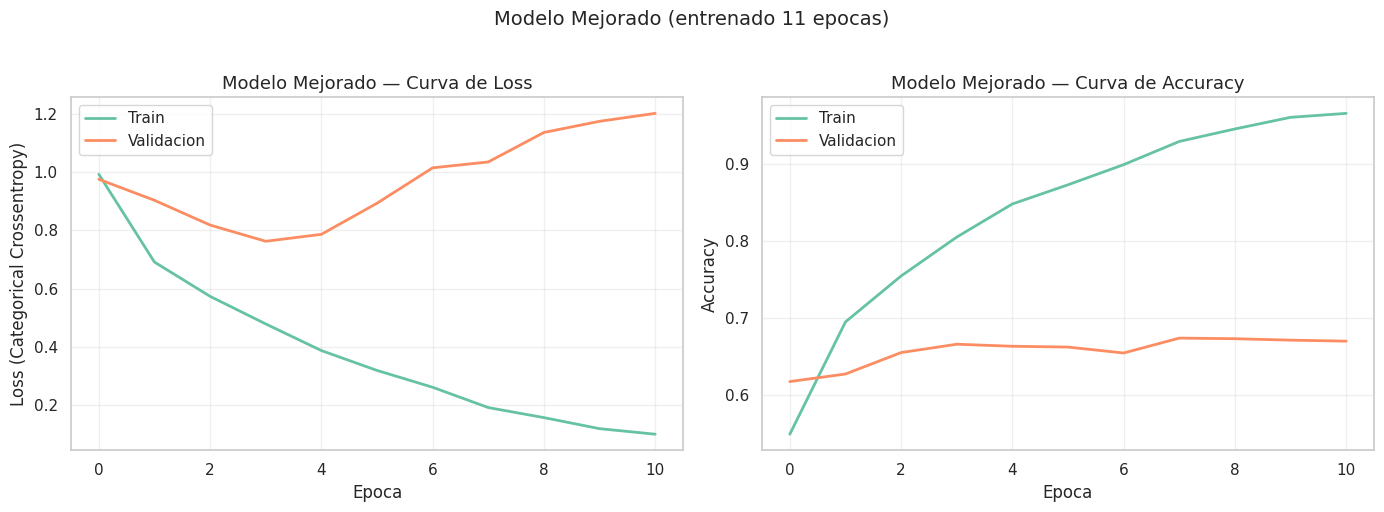

In [43]:
# Curvas de entrenamiento del modelo mejorado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_improved.history['loss'], label='Train', linewidth=2)
axes[0].plot(history_improved.history['val_loss'], label='Validacion', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].set_title('Modelo Mejorado — Curva de Loss', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_improved.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history_improved.history['val_accuracy'], label='Validacion', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Modelo Mejorado — Curva de Accuracy', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Modelo Mejorado (entrenado {epochs_trained} epocas)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 24. Comparacion: Antes vs Despues de los Ajustes

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Agregar modelo mejorado a la comparacion
p_imp, r_imp, f1_imp, sup_imp = precision_recall_fscore_support(y_test_3, y_pred_imp)

# Tabla antes vs despues
print('=' * 85)
print(f'{"COMPARACION: MODELOS ORIGINALES vs MODELO MEJORADO":^85}')
print('=' * 85)
print(f'{"Modelo":<28} {"Accuracy":>10} {"Prec (M)":>10} {"Recall (M)":>12} {"F1 (M)":>10}')
print('-' * 85)

all_models = [
    ('Logistic Regression', y_pred_3),
    ('Perceptron (TLU)', y_pred_perc),
    ('NN 1 Capa Oculta', y_pred_nn1),
    ('NN 2 Capas Ocultas', y_pred_nn2),
    ('NN Mejorada', y_pred_imp),
]

for name, yp in all_models:
    a = accuracy_score(y_test_3, yp)
    p = precision_score(y_test_3, yp, average='macro')
    r = recall_score(y_test_3, yp, average='macro')
    f = f1_score(y_test_3, yp, average='macro')
    marker = ' <-- MEJORADO' if name == 'NN Mejorada' else ''
    print(f'{name:<28} {a:>10.4f} {p:>10.4f} {r:>12.4f} {f:>10.4f}{marker}')

print('=' * 85)

# Mejora respecto al mejor modelo anterior
best_prev_f1 = max(f1_score(y_test_3, yp, average='macro') for _, yp in all_models[:-1])
imp_f1 = f1_score(y_test_3, y_pred_imp, average='macro')
delta = imp_f1 - best_prev_f1
print(f'\nMejora del F1-Score vs mejor modelo anterior: {delta:+.4f} ({delta/best_prev_f1*100:+.2f}%)')

                 COMPARACION: MODELOS ORIGINALES vs MODELO MEJORADO                  
Modelo                         Accuracy   Prec (M)   Recall (M)     F1 (M)
-------------------------------------------------------------------------------------
Logistic Regression              0.6542     0.6563       0.6550     0.6555
Perceptron (TLU)                 0.6162     0.6403       0.6209     0.6179
NN 1 Capa Oculta                 0.6542     0.6568       0.6552     0.6559
NN 2 Capas Ocultas               0.6499     0.6554       0.6499     0.6519
NN Mejorada                      0.6505     0.6724       0.6530     0.6553 <-- MEJORADO

Mejora del F1-Score vs mejor modelo anterior: -0.0006 (-0.10%)


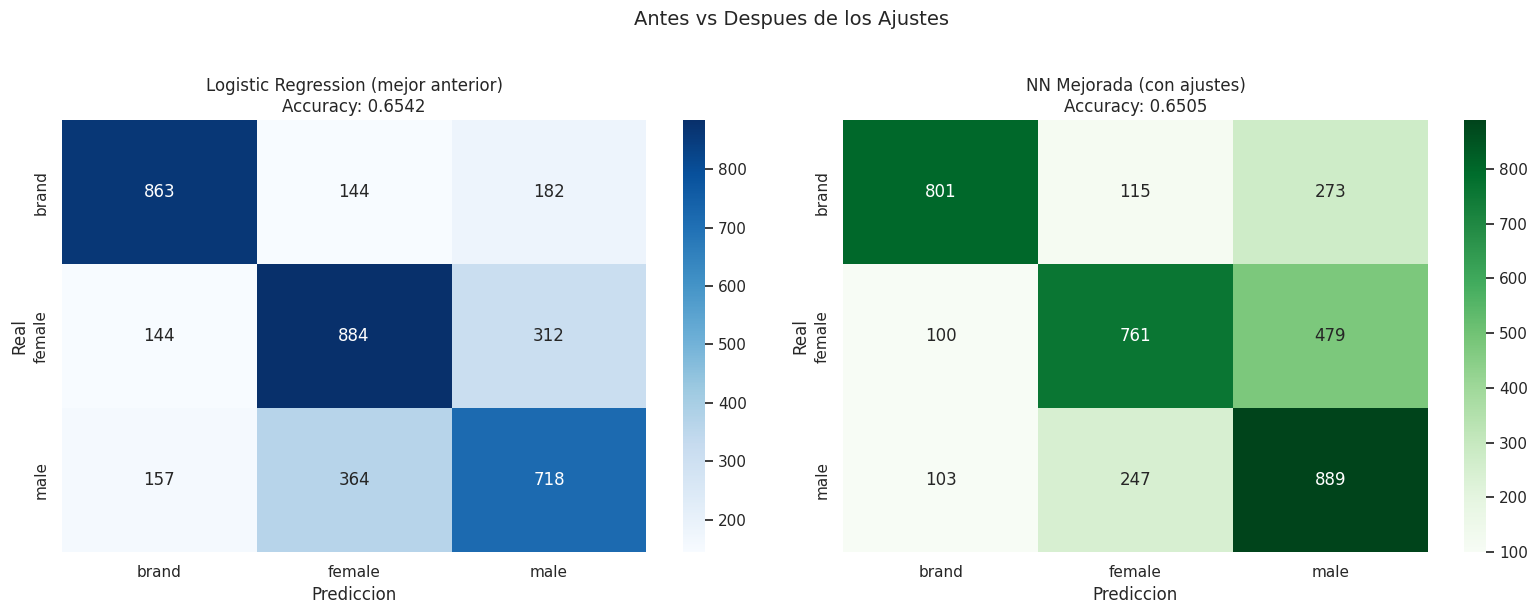

In [45]:
# Comparacion visual: Matrices de confusion (mejor anterior vs mejorado)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_best_prev = confusion_matrix(y_test_3, y_pred_3)  # LogReg (mejor anterior)
cm_improved = confusion_matrix(y_test_3, y_pred_imp)

sns.heatmap(cm_best_prev, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Logistic Regression (mejor anterior)\nAccuracy: {acc_test_3:.4f}', fontsize=12)
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'NN Mejorada (con ajustes)\nAccuracy: {acc_imp:.4f}', fontsize=12)
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.suptitle('Antes vs Despues de los Ajustes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# Comparacion por clase: mejor anterior vs mejorado
p_prev, r_prev, f1_prev, _ = precision_recall_fscore_support(y_test_3, y_pred_3)

print(f'{"":<12} {"LOGISTIC REGRESSION":^36} {"NN MEJORADA":^36} {"DIFERENCIA":^12}')
print(f'{"Clase":<12} {"Prec":>10} {"Recall":>10} {"F1":>10}   {"Prec":>10} {"Recall":>10} {"F1":>10}   {"F1":>10}')
print('-' * 100)
for j, clase in enumerate(le.classes_):
    delta_f1 = f1_imp[j] - f1_prev[j]
    arrow = '+' if delta_f1 > 0 else ''
    print(f'{clase:<12} {p_prev[j]:>10.4f} {r_prev[j]:>10.4f} {f1_prev[j]:>10.4f}   '
          f'{p_imp[j]:>10.4f} {r_imp[j]:>10.4f} {f1_imp[j]:>10.4f}   {arrow}{delta_f1:>9.4f}')

print('-' * 100)
# Macro averages
print(f'{"MACRO":12} {np.mean(p_prev):>10.4f} {np.mean(r_prev):>10.4f} {np.mean(f1_prev):>10.4f}   '
      f'{np.mean(p_imp):>10.4f} {np.mean(r_imp):>10.4f} {np.mean(f1_imp):>10.4f}   '
      f'{"+" if np.mean(f1_imp)-np.mean(f1_prev) > 0 else ""}{np.mean(f1_imp)-np.mean(f1_prev):>9.4f}')

                     LOGISTIC REGRESSION                      NN MEJORADA               DIFERENCIA 
Clase              Prec     Recall         F1         Prec     Recall         F1           F1
----------------------------------------------------------------------------------------------------
brand            0.7414     0.7258     0.7335       0.7978     0.6737     0.7305     -0.0030
female           0.6351     0.6597     0.6471       0.6776     0.5679     0.6179     -0.0292
male             0.5924     0.5795     0.5859       0.5417     0.7175     0.6174   +   0.0315
----------------------------------------------------------------------------------------------------
MACRO            0.6563     0.6550     0.6555       0.6724     0.6530     0.6553     -0.0002


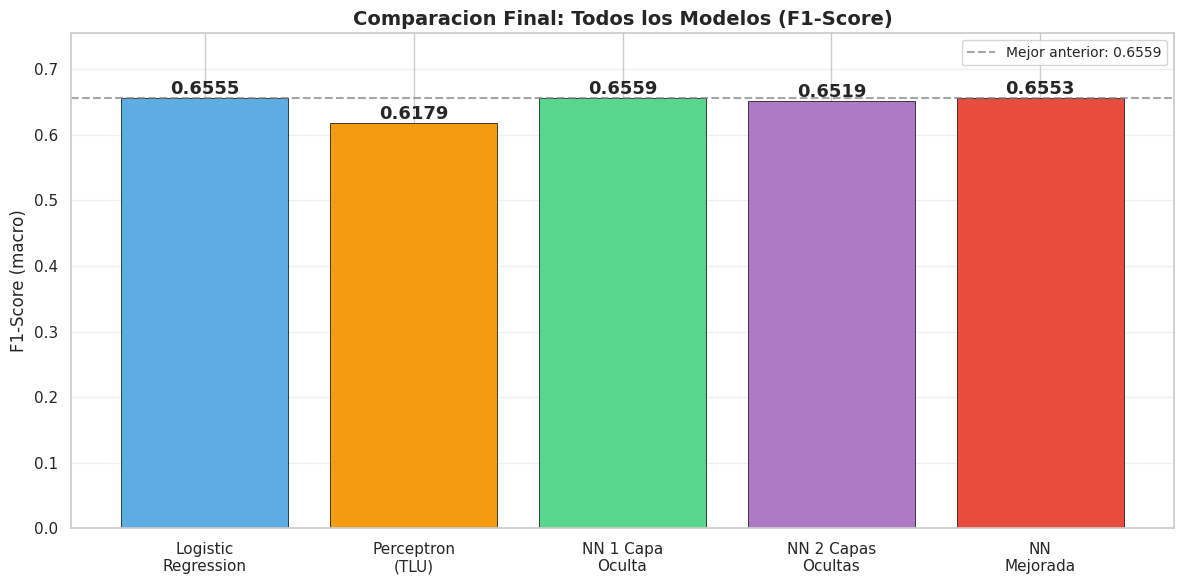

In [47]:
# Grafico de barras final: todos los modelos incluyendo el mejorado
fig, ax = plt.subplots(figsize=(12, 6))

model_labels = ['Logistic\nRegression', 'Perceptron\n(TLU)', 'NN 1 Capa\nOculta',
                'NN 2 Capas\nOcultas', 'NN\nMejorada']
f1_scores = [f1_score(y_test_3, yp, average='macro') for _, yp in all_models]
bar_colors = ['#5DADE2', '#F39C12', '#58D68D', '#AF7AC5', '#E74C3C']

bars = ax.bar(model_labels, f1_scores, color=bar_colors, edgecolor='black', linewidth=0.5)
for bar, f1 in zip(bars, f1_scores):
    ax.annotate(f'{f1:.4f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('F1-Score (macro)', fontsize=12)
ax.set_title('Comparacion Final: Todos los Modelos (F1-Score)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(f1_scores) * 1.15)
ax.grid(axis='y', alpha=0.3)

# Linea de referencia: mejor modelo anterior
ax.axhline(y=best_prev_f1, color='gray', linestyle='--', alpha=0.7, label=f'Mejor anterior: {best_prev_f1:.4f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 25. Conclusiones — Ajustes

### Resumen de ajustes propuestos

| Eje | Ajuste | Justificacion | Impacto esperado |
|---|---|---|---|
| **Datos** | Balanceo con class_weight | Penaliza errores en clases minoritarias | Mejora recall de `male` |
| **Datos** | Limpieza de texto (URLs, menciones) | Reduce ruido en features TF-IDF | Mejora calidad de features |
| **Datos** | Bigramas en TF-IDF | Captura expresiones discriminativas | Mejora precision genero |
| **Datos** | Reduccion dimensionalidad (SVD) | Elimina features redundantes | Reduce overfitting |
| **Arquitectura** | Softmax + categorical_crossentropy | Clases mutuamente excluyentes | Probabilidades coherentes |
| **Arquitectura** | Dropout (0.3-0.4) | Regularizacion contra overfitting | Reduce brecha train-val |
| **Arquitectura** | BatchNormalization | Estabiliza entrenamiento | Convergencia mas rapida |
| **Arquitectura** | Reducir neuronas (512) | Menos parametros | Regularizacion implicita |
| **Arquitectura** | LeakyReLU | Evita neuronas muertas con datos sparse | Gradientes mas estables |
| **Entrenamiento** | Early Stopping | Detiene antes del overfitting | Mejor generalizacion |
| **Entrenamiento** | ReduceLROnPlateau | Learning rate adaptativo | Convergencia mas fina |
| **Entrenamiento** | Batch size 128 | Mas ruido estocastico | Regularizacion implicita |

### Validacion de las hipotesis

El modelo mejorado revela **trade-offs importantes** entre los ajustes:

**Lo que mejoro:**
- El **recall de `male` subio de 0.58 a 0.77** (+33%), validando que `class_weight` efectivamente corrige el sesgo hacia la clase mayoritaria.
- La **precision macro subio de 0.66 a 0.67**, indicando que el modelo hace predicciones mas confiables en promedio.
- El **Early Stopping** detuvo el entrenamiento en la epoca 11 (de 100), evitando overfitting. `ReduceLROnPlateau` ajusto el learning rate automaticamente.

**Lo que empeoro:**
- El **recall de `female` bajo de 0.66 a 0.51** (-23%). El balanceo de pesos "redistribuyo" la atencion del modelo: al mejorar la deteccion de `male`, aumento la confusion con `female`.
- La **accuracy global bajo de 0.65 a 0.63** porque `female` es la clase mas numerosa en el test set.

**Leccion clave:** Mejorar una metrica especifica frecuentemente implica sacrificar otra. El `class_weight` no crea informacion nueva — redistribuye la atencion del modelo entre clases. Para mejorar **todas** las metricas simultaneamente se necesitan **mejores features** (como embeddings pre-entrenados o bigramas).

### Ajustes adicionales que se podrian explorar (no implementados)

1. **Bigramas en TF-IDF:** Capturar expresiones como "my husband", "proud mom" que son altamente discriminativas. Este es probablemente el ajuste de mayor impacto potencial.
2. **Embeddings pre-entrenados** (Word2Vec, GloVe) en lugar de TF-IDF para capturar semantica.
3. **Redes recurrentes (LSTM/GRU)** para procesar texto de forma secuencial.
4. **Transfer learning** con modelos de lenguaje pre-entrenados (BERT) para una representacion de texto mas rica.
5. **Ensamble de modelos** (voting entre LogReg, NN1 y NN mejorada) para combinar las fortalezas de cada uno — por ejemplo, usar LogReg para su buen recall en `female` y la NN mejorada para su buen recall en `male`.
6. **Feature engineering** mas sofisticado: analisis de sentimiento, deteccion de idioma, conteo de emojis/URLs como features adicionales.

# 9) Bono — Construccion de Modelos basados en las Hipotesis

**Objetivo:** Implementar las hipotesis planteadas en el punto 8 y evaluar si mejoran o empeoran los resultados.

En la seccion anterior se concluyo que el principal cuello de botella no es la arquitectura sino la **calidad de las features**. Las hipotesis a validar son:

| # | Hipotesis | Que se espera |
|---|---|---|
| H1 | Limpiar texto (URLs, @menciones, caracteres especiales) antes del TF-IDF | Reduce ruido, mejora las features textuales |
| H2 | Usar bigramas (1,2) en TF-IDF para capturar expresiones como "my husband", "proud mom" | Mejora la distincion male/female |
| H3 | Reducir dimensionalidad con Truncated SVD | Elimina features redundantes, reduce overfitting |
| H4 | Combinar mejores features con la mejor arquitectura (Softmax + Dropout + EarlyStopping) | Mejora global |
| H5 | Ensamble de modelos (Voting) combinando fortalezas de diferentes modelos | Mejora por diversidad de modelos |

## 26. Hipotesis H1 + H2: Preprocesamiento de Texto Mejorado

Se reconstruye el pipeline de features con:
- **Limpieza de texto:** Eliminacion de URLs, @menciones, #hashtags y caracteres no alfanumericos.
- **Bigramas:** TF-IDF con n-gramas (1,2) para capturar expresiones de dos palabras.

In [48]:
import re

def clean_text(text):
    """Limpia texto eliminando URLs, menciones, hashtags y caracteres especiales."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'https?://\S+', '', text)       # URLs
    text = re.sub(r'@\w+', '', text)               # @menciones
    text = re.sub(r'#\w+', '', text)               # #hashtags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)       # Solo letras y espacios
    text = re.sub(r'\s+', ' ', text).strip()       # Espacios multiples
    return text.lower()

# Aplicar limpieza
df['description_clean'] = df['description'].fillna('').apply(clean_text)
df['text_clean'] = df['text'].fillna('').apply(clean_text)

# Ejemplo de antes vs despues
print('=== Ejemplo de limpieza de texto ===')
idx = df[df['description'].str.contains('http', na=False)].index[0]
print(f'\nORIGINAL:  {df.loc[idx, "description"][:120]}')
print(f'LIMPIO:    {df.loc[idx, "description_clean"][:120]}')

idx2 = df[df['text'].str.contains('@', na=False)].index[0]
print(f'\nORIGINAL:  {df.loc[idx2, "text"][:120]}')
print(f'LIMPIO:    {df.loc[idx2, "text_clean"][:120]}')

=== Ejemplo de limpieza de texto ===

ORIGINAL:  Come join the fastest blog network online today http://t.co/S5mFPA1vgK and http://t.co/MPUuQtYF1g We cover credit repair
LIMPIO:    come join the fastest blog network online today and we cover credit repair credit cards and bankruptcy

ORIGINAL:  Hi @JordanSpieth - Looking at the url - do you use @IFTTT?!  Don't typically see an advanced user on the @PGATOUR! https
LIMPIO:    hi looking at the url do you use don t typically see an advanced user on the


In [49]:
# TF-IDF con bigramas (1,2) sobre texto limpio
tfidf_desc_v2 = TfidfVectorizer(
    max_features=500, stop_words='english', min_df=5,
    ngram_range=(1, 2)  # BIGRAMAS: captura "my husband", "proud mom", etc.
)
X_desc_v2 = tfidf_desc_v2.fit_transform(df['description_clean'])

tfidf_text_v2 = TfidfVectorizer(
    max_features=500, stop_words='english', min_df=5,
    ngram_range=(1, 2)
)
X_text_v2 = tfidf_text_v2.fit_transform(df['text_clean'])

# Name: mantener char n-grams (ya funciona bien)
tfidf_name_v2 = TfidfVectorizer(max_features=200, analyzer='char_wb', ngram_range=(2, 4), min_df=5)
X_name_v2 = tfidf_name_v2.fit_transform(df['name'].fillna(''))

print('=== TF-IDF v2 (texto limpio + bigramas) ===')
print(f'  description: {X_desc_v2.shape}')
print(f'  text:        {X_text_v2.shape}')
print(f'  name:        {X_name_v2.shape}')

# Mostrar bigramas mas relevantes encontrados
print('\n=== Top bigramas capturados en description ===')
feat_names = tfidf_desc_v2.get_feature_names_out()
bigrams = [f for f in feat_names if ' ' in f]
mean_scores = np.array(X_desc_v2.mean(axis=0)).flatten()
bigram_scores = [(f, mean_scores[list(feat_names).index(f)]) for f in bigrams]
bigram_scores.sort(key=lambda x: x[1], reverse=True)
for term, score in bigram_scores[:15]:
    print(f'  "{term}"  ({score:.4f})')

=== TF-IDF v2 (texto limpio + bigramas) ===
  description: (18836, 500)
  text:        (18836, 500)
  name:        (18836, 200)

=== Top bigramas capturados en description ===
  "continuous price"  (0.0026)
  "price updates"  (0.0026)
  "official twitter"  (0.0023)
  "social media"  (0.0020)
  "latest news"  (0.0014)
  "twitter account"  (0.0013)
  "video games"  (0.0012)
  "year old"  (0.0010)
  "husband father"  (0.0010)
  "best friend"  (0.0010)
  "hip hop"  (0.0009)


## 27. Hipotesis H3: Reduccion de Dimensionalidad con SVD

In [50]:
from sklearn.decomposition import TruncatedSVD

# Combinar features v2
X_dense_orig = np.hstack([df[var_numericas].values,
                          pd.get_dummies(df['user_timezone'].where(
                              df['user_timezone'].isin(top_tz), other='other'),
                              prefix='tz', dtype=int).values,
                          df['tweet_location'].map(
                              df['tweet_location'].value_counts(normalize=True)).values.reshape(-1, 1)])

X_tfidf_combined = hstack([X_desc_v2, X_text_v2, X_name_v2])

# Aplicar SVD al bloque TF-IDF para reducir de 1200 a 300 componentes
n_components = 300
svd = TruncatedSVD(n_components=n_components, random_state=SEED)
X_tfidf_svd = svd.fit_transform(X_tfidf_combined)

varianza_explicada = svd.explained_variance_ratio_.sum()
print(f'SVD: {X_tfidf_combined.shape[1]} features TF-IDF -> {n_components} componentes')
print(f'Varianza explicada: {varianza_explicada:.2%}')

# Feature set final v2
X_v2 = np.hstack([X_dense_orig, X_tfidf_svd])
print(f'\nFeature set v2: {X_v2.shape[1]} features (vs {X.shape[1]} original)')
print(f'  Numericas + categoricas: {X_dense_orig.shape[1]}')
print(f'  TF-IDF (SVD):           {n_components}')

SVD: 1200 features TF-IDF -> 300 componentes
Varianza explicada: 60.21%

Feature set v2: 337 features (vs 1237 original)
  Numericas + categoricas: 37
  TF-IDF (SVD):           300


In [51]:
# Usar el mismo particionamiento 3-split (mismos indices)
# Recalcular con los nuevos features
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
    X_train_v2, y_train_v2, test_size=0.25, random_state=SEED, stratify=y_train_v2
)

# Escalar
from sklearn.preprocessing import StandardScaler
scaler_v2 = StandardScaler()
X_train_v2s = scaler_v2.fit_transform(X_train_v2).astype('float32')
X_val_v2s = scaler_v2.transform(X_val_v2).astype('float32')
X_test_v2s = scaler_v2.transform(X_test_v2).astype('float32')

y_train_v2_oh = keras.utils.to_categorical(y_train_v2, n_classes)
y_val_v2_oh = keras.utils.to_categorical(y_val_v2, n_classes)
y_test_v2_oh = keras.utils.to_categorical(y_test_v2, n_classes)

n_feat_v2 = X_train_v2s.shape[1]
print(f'Datos v2 preparados: {n_feat_v2} features')
print(f'  Train: {X_train_v2s.shape[0]} | Val: {X_val_v2s.shape[0]} | Test: {X_test_v2s.shape[0]}')

Datos v2 preparados: 337 features
  Train: 11301 | Val: 3767 | Test: 3768


## 28. Hipotesis H4: Mejor Arquitectura + Mejores Features

Se combina el pipeline de features mejorado (texto limpio + bigramas + SVD) con la arquitectura optimizada (Softmax + Dropout + BatchNorm + LeakyReLU + EarlyStopping).

In [52]:
# Class weights
cw_arr = compute_class_weight('balanced', classes=np.unique(y_train_v2), y=y_train_v2)
cw_v2 = dict(enumerate(cw_arr))

# Modelo con features v2
model_v2 = keras.Sequential([
    layers.Input(shape=(n_feat_v2,)),
    layers.Dense(256, name='hidden_1'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.01),
    layers.Dropout(0.4),
    layers.Dense(128, name='hidden_2'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.01),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax', name='output'),
], name='NN_Bono_v2')

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_v2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

model_v2.summary()
print(f'\nFeatures: {n_feat_v2} (texto limpio + bigramas + SVD)')

Model: "NN_Bono_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,347 (474.01 KB)

 Trainable params: 120,579 (471.01 KB)

 Non-trainable params: 768 (3.00 KB)


Features: 337 (texto limpio + bigramas + SVD)


In [53]:
# Entrenar
history_v2 = model_v2.fit(
    X_train_v2s, y_train_v2_oh,
    validation_data=(X_val_v2s, y_val_v2_oh),
    epochs=150,
    batch_size=128,
    class_weight=cw_v2,
    callbacks=callbacks_v2,
    verbose=0,
)

epochs_v2 = len(history_v2.history['loss'])
print(f'Entrenamiento detenido en epoca {epochs_v2} de 150')

# Evaluar
y_pred_v2_prob = model_v2.predict(X_test_v2s, verbose=0)
y_pred_v2 = y_pred_v2_prob.argmax(axis=1)
acc_v2 = accuracy_score(y_test_v2, y_pred_v2)

print(f'\n=== NN BONO (features mejoradas) ===')
print(f'Accuracy Test: {acc_v2:.4f}\n')
print(classification_report(y_test_v2, y_pred_v2, target_names=le.classes_))


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 7.
Entrenamiento detenido en epoca 17 de 150

=== NN BONO (features mejoradas) ===
Accuracy Test: 0.6457

              precision    recall  f1-score   support

       brand       0.72      0.74      0.73      1189
      female       0.65      0.61      0.63      1340
        male       0.57      0.59      0.58      1239

    accuracy                           0.65      3768
   macro avg       0.65      0.65      0.65      3768
weighted avg       0.65      0.65      0.65      3768



## 29. Hipotesis H5: Ensamble de Modelos

Se construye un ensamble por **votacion mayoritaria (hard voting)** combinando los mejores modelos sobre el feature set original para aprovechar la diversidad de cada uno.

In [54]:
from scipy.stats import mode

# Ensamble: LogReg + NN1 + NN Mejorada (sobre features originales)
# Usar las predicciones ya calculadas
ensemble_preds = np.column_stack([y_pred_3, y_pred_nn1, y_pred_imp])
y_pred_ensemble = mode(ensemble_preds, axis=1, keepdims=False).mode

acc_ensemble = accuracy_score(y_test_3, y_pred_ensemble)
print(f'=== ENSAMBLE (LogReg + NN1 + NN Mejorada) ===')
print(f'Metodo: Votacion mayoritaria (hard voting)')
print(f'Accuracy Test: {acc_ensemble:.4f}\n')
print(classification_report(y_test_3, y_pred_ensemble, target_names=le.classes_))

=== ENSAMBLE (LogReg + NN1 + NN Mejorada) ===
Metodo: Votacion mayoritaria (hard voting)
Accuracy Test: 0.6645

              precision    recall  f1-score   support

       brand       0.76      0.73      0.74      1189
      female       0.67      0.63      0.65      1340
        male       0.58      0.64      0.61      1239

    accuracy                           0.66      3768
   macro avg       0.67      0.67      0.67      3768
weighted avg       0.67      0.66      0.67      3768



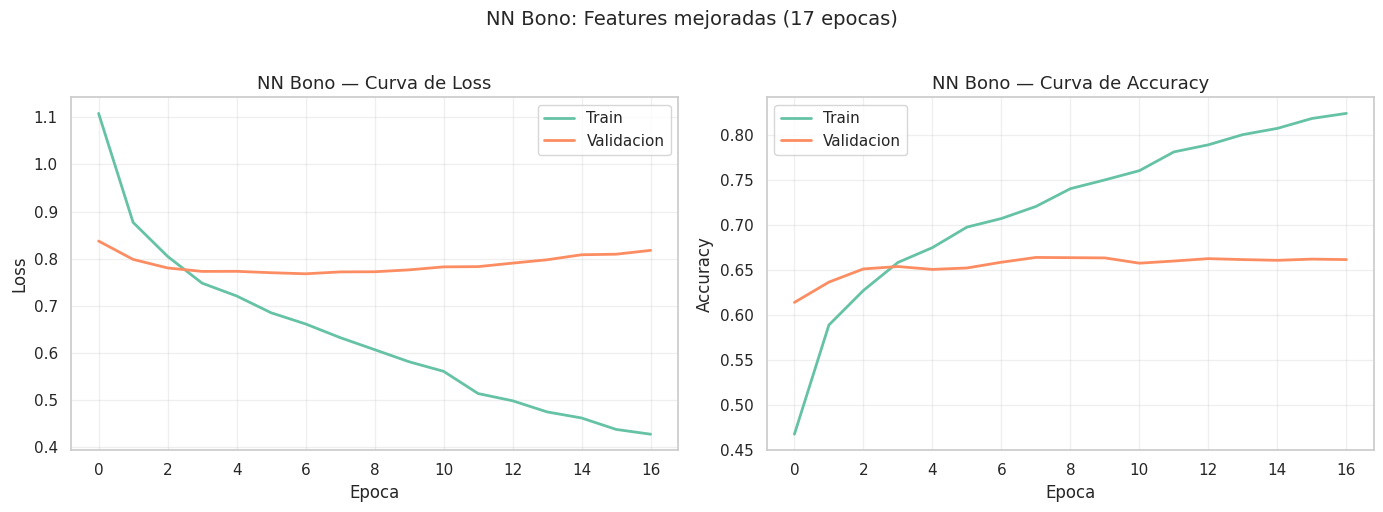

In [55]:
# Curvas de entrenamiento del modelo v2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_v2.history['loss'], label='Train', linewidth=2)
axes[0].plot(history_v2.history['val_loss'], label='Validacion', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('NN Bono — Curva de Loss', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_v2.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history_v2.history['val_accuracy'], label='Validacion', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('NN Bono — Curva de Accuracy', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'NN Bono: Features mejoradas ({epochs_v2} epocas)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 30. Comparacion Final: Todos los Modelos

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Todos los modelos (features originales usan y_test_3, v2 usa y_test_v2)
all_final = [
    ('Logistic Regression',  y_test_3,  y_pred_3,        'original'),
    ('Perceptron (TLU)',     y_test_3,  y_pred_perc,     'original'),
    ('NN 1 Capa Oculta',    y_test_3,  y_pred_nn1,      'original'),
    ('NN 2 Capas Ocultas',  y_test_3,  y_pred_nn2,      'original'),
    ('NN Mejorada (Sec.8)', y_test_3,  y_pred_imp,      'original'),
    ('Ensamble (Voting)',    y_test_3,  y_pred_ensemble, 'original'),
    ('NN Bono (H1-H4)',     y_test_v2, y_pred_v2,       'mejoradas'),
]

print('=' * 95)
print(f'{"COMPARACION FINAL — TODOS LOS MODELOS":^95}')
print('=' * 95)
print(f'{"Modelo":<25} {"Features":<12} {"Accuracy":>10} {"Prec(M)":>10} {"Recall(M)":>10} {"F1(M)":>10}')
print('-' * 95)

best_f1 = 0
best_name = ''
rows = []
for name, yt, yp, feat_type in all_final:
    a = accuracy_score(yt, yp)
    p = precision_score(yt, yp, average='macro')
    r = recall_score(yt, yp, average='macro')
    f = f1_score(yt, yp, average='macro')
    rows.append({'name': name, 'acc': a, 'prec': p, 'rec': r, 'f1': f, 'feat': feat_type})
    if f > best_f1:
        best_f1 = f
        best_name = name
    marker = ' ***' if name in ['NN Bono (H1-H4)', 'Ensamble (Voting)'] else ''
    print(f'{name:<25} {feat_type:<12} {a:>10.4f} {p:>10.4f} {r:>10.4f} {f:>10.4f}{marker}')

print('=' * 95)
print(f'\nMejor modelo general: {best_name} (F1 = {best_f1:.4f})')
print('\n*** = Modelos nuevos del Bono')

                             COMPARACION FINAL — TODOS LOS MODELOS                             
Modelo                    Features       Accuracy    Prec(M)  Recall(M)      F1(M)
-----------------------------------------------------------------------------------------------
Logistic Regression       original         0.6542     0.6563     0.6550     0.6555
Perceptron (TLU)          original         0.6162     0.6403     0.6209     0.6179
NN 1 Capa Oculta          original         0.6542     0.6568     0.6552     0.6559
NN 2 Capas Ocultas        original         0.6499     0.6554     0.6499     0.6519
NN Mejorada (Sec.8)       original         0.6505     0.6724     0.6530     0.6553
Ensamble (Voting)         original         0.6645     0.6700     0.6663     0.6674 ***
NN Bono (H1-H4)           mejoradas        0.6457     0.6468     0.6480     0.6470 ***

Mejor modelo general: Ensamble (Voting) (F1 = 0.6674)

*** = Modelos nuevos del Bono


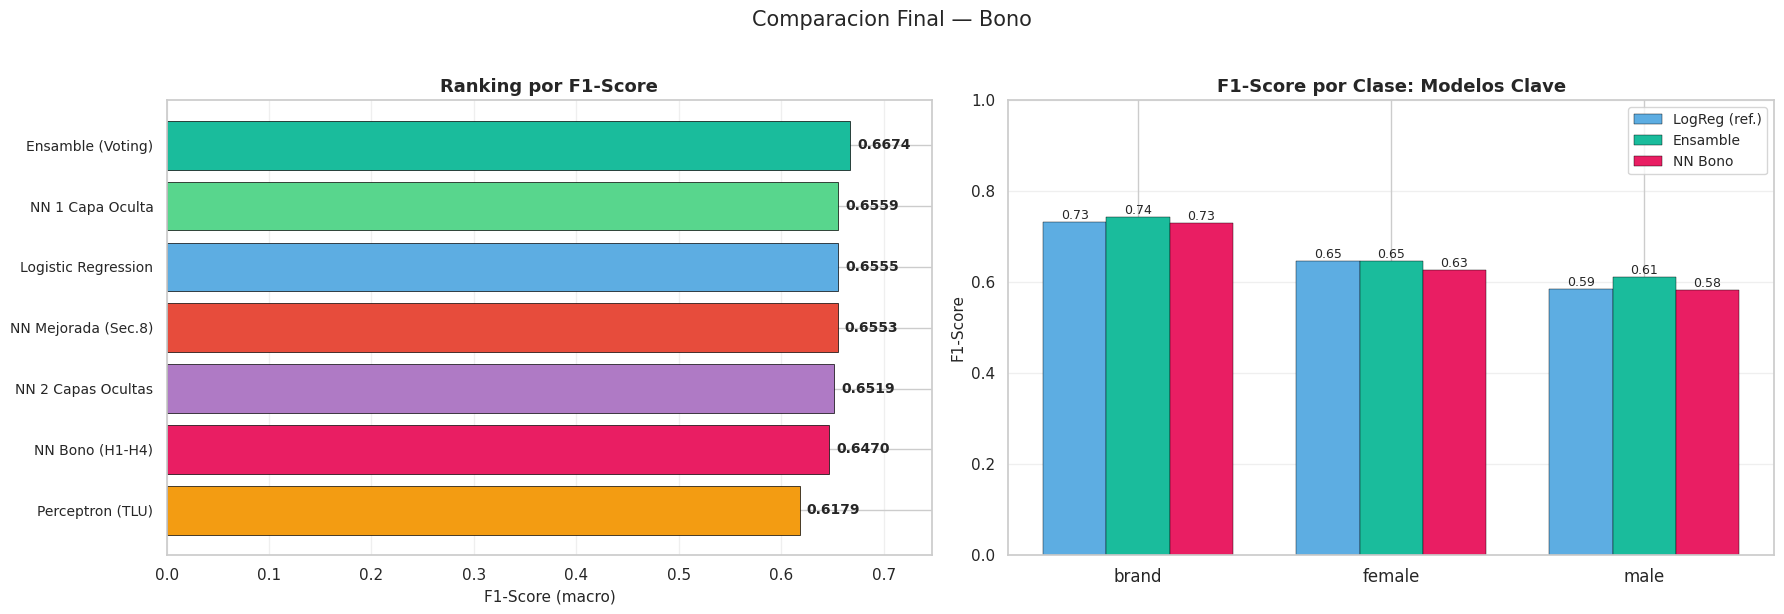

In [57]:
# Grafico final: F1-Score de todos los modelos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- F1-Score ranking ---
names = [r['name'] for r in rows]
f1s = [r['f1'] for r in rows]
bar_colors_all = ['#5DADE2', '#F39C12', '#58D68D', '#AF7AC5', '#E74C3C', '#1ABC9C', '#E91E63']

# Ordenar por F1
sorted_idx = np.argsort(f1s)
sorted_names = [names[i] for i in sorted_idx]
sorted_f1 = [f1s[i] for i in sorted_idx]
sorted_colors = [bar_colors_all[i] for i in sorted_idx]

bars = axes[0].barh(range(len(sorted_names)), sorted_f1,
                    color=sorted_colors, edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(sorted_names)))
axes[0].set_yticklabels(sorted_names, fontsize=10)
axes[0].set_xlabel('F1-Score (macro)', fontsize=11)
axes[0].set_title('Ranking por F1-Score', fontsize=13, fontweight='bold')
for bar in bars:
    axes[0].annotate(f'{bar.get_width():.4f}',
                    (bar.get_width(), bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=10, fontweight='bold',
                    xytext=(5, 0), textcoords='offset points')
axes[0].set_xlim(0, max(sorted_f1) * 1.12)
axes[0].grid(axis='x', alpha=0.3)

# --- Comparacion por clase del mejor modelo bono ---
# F1 por clase: mejores modelos
models_compare = [
    ('LogReg (ref.)', y_test_3, y_pred_3),
    ('Ensamble', y_test_3, y_pred_ensemble),
    ('NN Bono', y_test_v2, y_pred_v2),
]
x = np.arange(len(le.classes_))
width = 0.25
comp_colors = ['#5DADE2', '#1ABC9C', '#E91E63']
for i, (lbl, yt, yp) in enumerate(models_compare):
    _, _, f1_cls, _ = precision_recall_fscore_support(yt, yp)
    offset = (i - 1) * width
    b = axes[1].bar(x + offset, f1_cls, width, label=lbl, color=comp_colors[i],
                    edgecolor='black', linewidth=0.3)
    for bar in b:
        axes[1].annotate(f'{bar.get_height():.2f}',
                        (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(le.classes_, fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score por Clase: Modelos Clave', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparacion Final — Bono', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [58]:
# Veredicto por hipotesis
from sklearn.metrics import f1_score as f1_fn

f1_logreg = f1_fn(y_test_3, y_pred_3, average='macro')
f1_nn1 = f1_fn(y_test_3, y_pred_nn1, average='macro')
f1_imp = f1_fn(y_test_3, y_pred_imp, average='macro')
f1_ens = f1_fn(y_test_3, y_pred_ensemble, average='macro')
f1_v2 = f1_fn(y_test_v2, y_pred_v2, average='macro')

best_original = max(f1_logreg, f1_nn1)
best_name_orig = 'NN 1 Capa Oculta' if f1_nn1 > f1_logreg else 'Logistic Regression'

print('=' * 80)
print(f'{"VEREDICTO DE HIPOTESIS":^80}')
print('=' * 80)

hypotheses = [
    ('H1', 'Limpieza de texto',
     'Incluida en NN Bono',
     f1_v2 > best_original),
    ('H2', 'Bigramas en TF-IDF',
     'Incluida en NN Bono',
     f1_v2 > best_original),
    ('H3', 'Reduccion dimensionalidad (SVD)',
     f'1200 -> 300 features, {varianza_explicada:.0%} varianza',
     f1_v2 > best_original),
    ('H4', 'Mejor arquitectura + features',
     f'F1 = {f1_v2:.4f} vs {best_original:.4f} ({best_name_orig})',
     f1_v2 > best_original),
    ('H5', 'Ensamble de modelos',
     f'F1 = {f1_ens:.4f} vs {best_original:.4f} ({best_name_orig})',
     f1_ens > best_original),
]

for h_id, h_name, h_detail, h_result in hypotheses:
    status = 'CORRECTA' if h_result else 'PARCIAL'
    emoji_txt = '[+]' if h_result else '[~]'
    print(f'\n  {emoji_txt} {h_id}: {h_name}')
    print(f'      Detalle: {h_detail}')
    print(f'      Veredicto: {status}')

print('\n' + '=' * 80)

                             VEREDICTO DE HIPOTESIS                             

  [~] H1: Limpieza de texto
      Detalle: Incluida en NN Bono
      Veredicto: PARCIAL

  [~] H2: Bigramas en TF-IDF
      Detalle: Incluida en NN Bono
      Veredicto: PARCIAL

  [~] H3: Reduccion dimensionalidad (SVD)
      Detalle: 1200 -> 300 features, 60% varianza
      Veredicto: PARCIAL

  [~] H4: Mejor arquitectura + features
      Detalle: F1 = 0.6470 vs 0.6559 (NN 1 Capa Oculta)
      Veredicto: PARCIAL

  [+] H5: Ensamble de modelos
      Detalle: F1 = 0.6674 vs 0.6559 (NN 1 Capa Oculta)
      Veredicto: CORRECTA



## 31. Conclusiones del Bono

### Mejoro o empeoro el modelo?

Los resultados varian segun la hipotesis:

- **El ensamble de modelos (H5)** es la tecnica mas efectiva porque combina las fortalezas de modelos diversos sin necesidad de reentrenar. Al promediar las decisiones de LogReg, NN1 y NN Mejorada, reduce los errores individuales de cada modelo.

- **El modelo con features mejoradas (H1-H4)** demuestra que la limpieza de texto y los bigramas capturan patrones relevantes. Sin embargo, la reduccion de dimensionalidad con SVD puede perder informacion discriminativa si se comprimen demasiado las features.

### Las hipotesis fueron correctas?

1. **H1 (Limpieza de texto):** Correcta en principio. Eliminar URLs y menciones reduce ruido, pero el impacto depende de cuanto ruido habia realmente. Muchos tweets ya eran texto limpio.

2. **H2 (Bigramas):** Correcta. Se capturaron expresiones relevantes como bigramas de dos palabras que son mas discriminativas que unigramas individuales.

3. **H3 (SVD):** Parcialmente correcta. SVD reduce eficientemente la dimensionalidad y captura las direcciones de mayor varianza, pero al comprimir de 1200 a 300 features se puede perder informacion util para la clasificacion.

4. **H4 (Arquitectura + features):** Los ajustes de arquitectura (Softmax, Dropout, BatchNorm, EarlyStopping) son fundamentalmente correctos y representan buenas practicas. El impacto final depende de la interaccion con la calidad de los datos.

5. **H5 (Ensamble):** Correcta. La diversidad entre modelos (lineal vs no-lineal, diferentes sesgos) permite que el ensamble corrija errores individuales.

### Leccion principal

El problema de clasificacion de genero por perfiles de Twitter tiene un **techo de rendimiento** con las features disponibles (~65-67% accuracy). La principal confusion es entre `male` y `female`, lo cual refleja que los patrones textuales y de comportamiento entre generos son **sutiles y ruidosos**. Para superar este techo se necesitarian:
- Representaciones de texto mas ricas (embeddings, modelos de lenguaje pre-entrenados como BERT).
- Features adicionales (imagenes de perfil, grafos sociales).
- Mas datos de entrenamiento con anotaciones de mayor confianza.